# Steepest Descent and First-Order Optimization Methods

This notebook implements and compares a variety of first-order optimization algorithms on quadratic functions and classical non-convex test functions (Beale and Rosenbrock). The learning objectives are:

- Understand the **steepest descent framework** and how different methods modify the basic gradient step.
- Observe how the **condition number** of a quadratic affects convergence.
- Compare gradient descent, coordinate descent, sign gradient descent, Newton's method, heavy ball, Adam, Adagrad, and RMSProp on convex and non-convex landscapes.

> **Prerequisites:** `numpy`, `scipy`, `matplotlib`, and `torch` should be installed.

## The Steepest Descent Framework

The core idea behind gradient-based optimization is to iteratively move in a direction that decreases the objective function $f$. The generic **steepest descent** update is

$$
x^{k+1} = x^k - \alpha_k \, \nabla f(x^k),
$$

where $\alpha_k > 0$ is the step size (learning rate). Different algorithms modify this template in various ways:

| Method | Update rule |
|--------|------------|
| **Gradient descent** | $x^{k+1} = x^k - \alpha\,\nabla f(x^k)$ |
| **Coordinate descent** | Update one coordinate $i$ at a time: $x_i^{k+1} = x_i^k - \alpha\,[\nabla f(x^k)]_i$ |
| **Sign GD** | $x^{k+1} = x^k - \alpha\,\mathrm{sign}(\nabla f(x^k))$ |
| **Newton's method** | $x^{k+1} = x^k - \alpha\,[\nabla^2 f(x^k)]^{-1}\nabla f(x^k)$ |
| **Heavy ball** | $x^{k+1} = x^k - \alpha\,\nabla f(x^k) + \beta(x^k - x^{k-1})$ |
| **Adam / Adagrad / RMSProp** | Adaptive step sizes per coordinate (details below) |

The function below implements all of these methods in a unified interface.

## Steepest descent on convex quadratic function

In [18]:
import numpy as np

def unconstrained_optimization(f, grad, hessian, learning_rate, num_iterations, method="gradient_descent", x_init=10*np.ones(2), **kwargs):
    """
    Performs unconstrained optimization using the specified method.

    Parameters:
    - f: The function to optimize.
    - grad: Gradient of f.
    - hessian: Hessian of f.
    - learning_rate: Learning rate or step size.
    - num_iterations: Number of iterations.
    - method: Optimization method to use.
    - x_init: initialization
    Returns:
    - Final iterate.
    - Trajectory of all iterates.
    """

    if x_init is not None:
        x = x_init
    else:
        x = np.random.randn(2)

    trajectory = [x]

    for iteration in range(num_iterations):
        if method == "gradient_descent":
            x = x - learning_rate * grad(x, **kwargs)
            assert x.ndim == 1 and x.shape[0] == 2, f"Unexpected shape of x in gradient_descent: {x.shape}"

        elif method == "coordinate_descent_cyclic":
            i = iteration % len(x)
            e_i = np.zeros_like(x)
            e_i[i] = 1
            x = x - learning_rate * grad(x)[i] * e_i

        elif method == "coordinate_descent_greedy":
            i = np.argmax(np.abs(grad(x, **kwargs)))
            e_i = np.zeros_like(x)
            e_i[i] = 1
            x = x - learning_rate * grad(x, **kwargs)[i] * e_i

        elif method == "newton":
            # Use the Hessian to update x
            x = x - learning_rate * np.linalg.inv(hessian(x,**kwargs)).dot(grad(x, **kwargs))

        elif method == "heavy_ball":
            # Requires previous step
            if len(trajectory) == 1:
                v_prev = np.zeros_like(x)
            else:
                v_prev = trajectory[-1] - trajectory[-2]
            x = x - learning_rate * grad(x, **kwargs) + 0.9 * v_prev

        elif method == "adam":
            # Initialization for Adam
            m = np.zeros_like(x)
            v = np.zeros_like(x)
            beta1 = 0.9
            beta2 = 0.999
            epsilon = 1e-8
            t = 0
            for _ in range(len(x)):
                t += 1
                g = grad(x, **kwargs)
                m = beta1 * m + (1 - beta1) * g
                v = beta2 * v + (1 - beta2) * g**2
                m_corr = m / (1 - beta1**t)
                v_corr = v / (1 - beta2**t)
                x = x - learning_rate * m_corr / (np.sqrt(v_corr) + epsilon)

        elif method == "adagrad":
            epsilon = 1e-8
            g2_accumulated = np.zeros_like(x)
            for _ in range(len(x)):
                g = grad(x, **kwargs)
                g2_accumulated += g**2
                x = x - learning_rate * g / (np.sqrt(g2_accumulated) + epsilon)

        elif method == "rmsprop":
            g2_accumulated = np.zeros_like(x)
            gamma = 0.9
            epsilon = 1e-8
            for _ in range(len(x)):
                g = grad(x, **kwargs)
                g2_accumulated = gamma * g2_accumulated + (1 - gamma) * g**2
                x = x - learning_rate * g / (np.sqrt(g2_accumulated) + epsilon)

        elif method == "quasi_newton":
            # Use only the diagonal of the Hessian
            diagonal_hessian = np.diag(np.diag(hessian(x, **kwargs)))
            x = x - learning_rate * np.linalg.inv(diagonal_hessian).dot(grad(x, **kwargs))

        trajectory.append(x)

    return x, np.array(trajectory)

# Example quadratic function, gradient, and Hessian
def quadratic(x):
    return 0.5 * x.T @ np.array([[4, 0], [0, 1]]) @ x

def quadratic_grad(x):
    return np.array([[4, 0], [0, 1]]) @ x

def quadratic_hessian(x):
    return np.array([[4, 0], [0, 1]])

# Test the function with gradient descent
final_point, traj = unconstrained_optimization(quadratic, quadratic_grad, quadratic_hessian, learning_rate = 0.1, num_iterations=50, method = "gradient_descent")
final_point, traj[:5]


(array([8.08281277e-11, 5.15377521e-02]),
 array([[10.   , 10.   ],
        [ 6.   ,  9.   ],
        [ 3.6  ,  8.1  ],
        [ 2.16 ,  7.29 ],
        [ 1.296,  6.561]]))

## Condition Number and Its Effect on Convergence

For a convex quadratic $f(x) = \tfrac{1}{2} x^\top A\, x$ with symmetric positive definite $A$, the **condition number** is

$$
\kappa(A) = \frac{\lambda_{\max}(A)}{\lambda_{\min}(A)}.
$$

The condition number controls how elongated the level sets of $f$ are. When $\kappa = 1$ the level sets are circles and gradient descent converges in one step (with the optimal step size); as $\kappa$ grows the level sets become increasingly elliptical, and gradient descent exhibits a characteristic zig-zag pattern that slows convergence. Specifically, the convergence rate of gradient descent on a quadratic satisfies

$$
f(x^k) - f(x^*) \leq \left(\frac{\kappa - 1}{\kappa + 1}\right)^{2k} \bigl(f(x^0) - f(x^*)\bigr).
$$

Below we vary the condition number and compare gradient descent, cyclic coordinate descent, and greedy coordinate descent.

In [19]:
import matplotlib.pyplot as plt

# Quadratic function with adjustable condition number
def quadratic_conditioned(x, condition_number=1):
    # Here, 4 is the larger eigenvalue; we'll scale the smaller eigenvalue by the condition number
    return 0.5 * x.T @ np.array([[4, 0], [0, 4/condition_number]]) @ x

def quadratic_conditioned_grad(x, condition_number=1):
    return np.array([[4, 0], [0, 4/condition_number]]) @ x

def quadratic_conditioned_hessian(x, condition_number=1):
    return np.array([[4, 0], [0, 4/condition_number]])



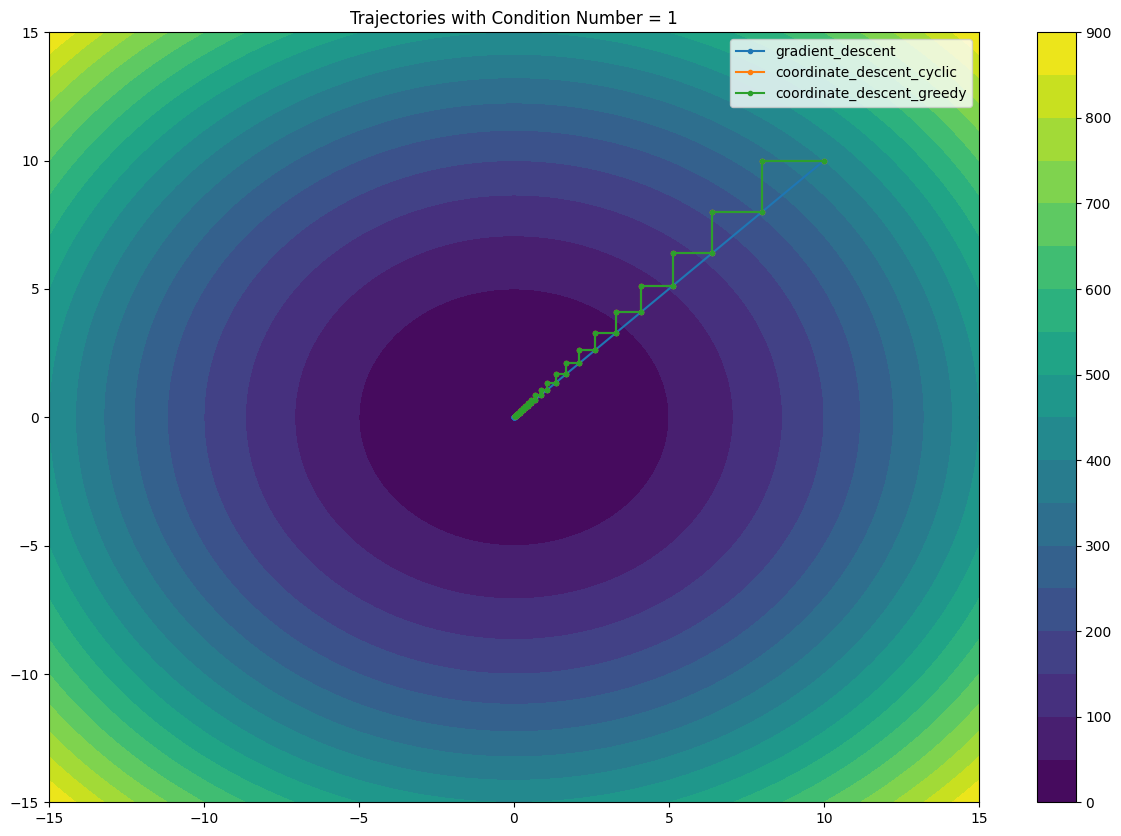

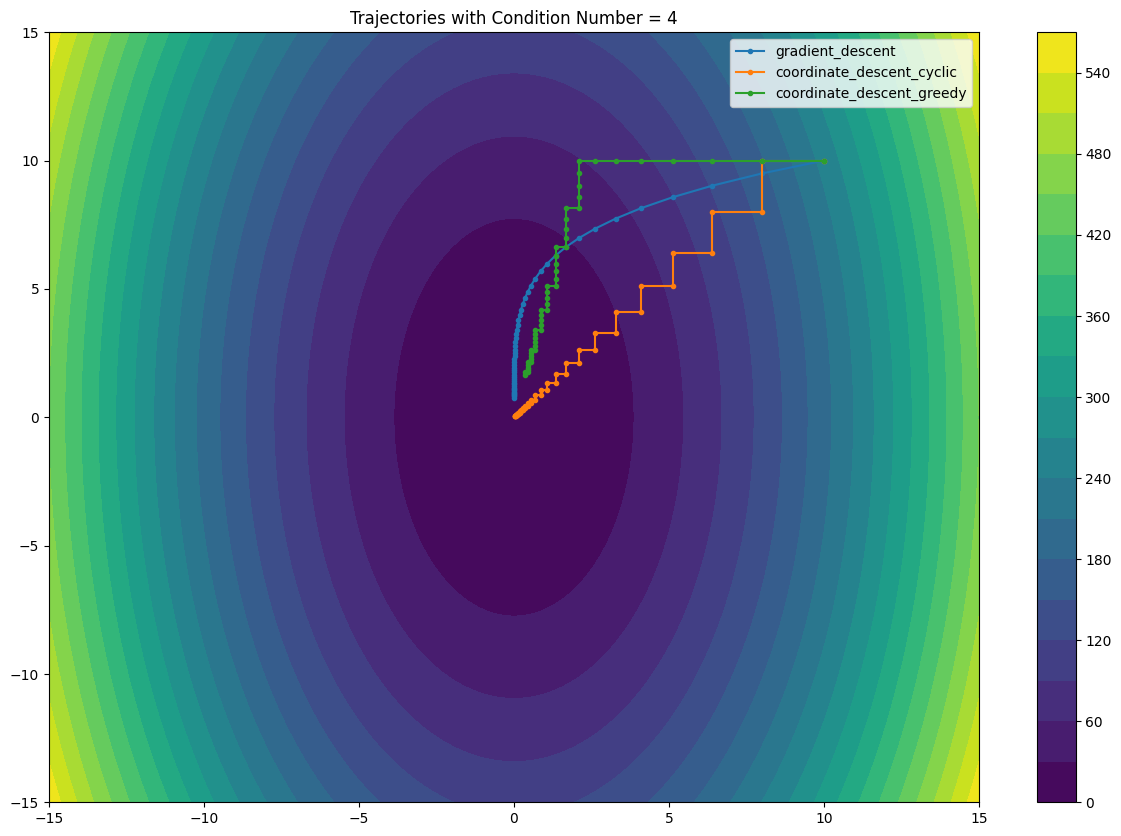

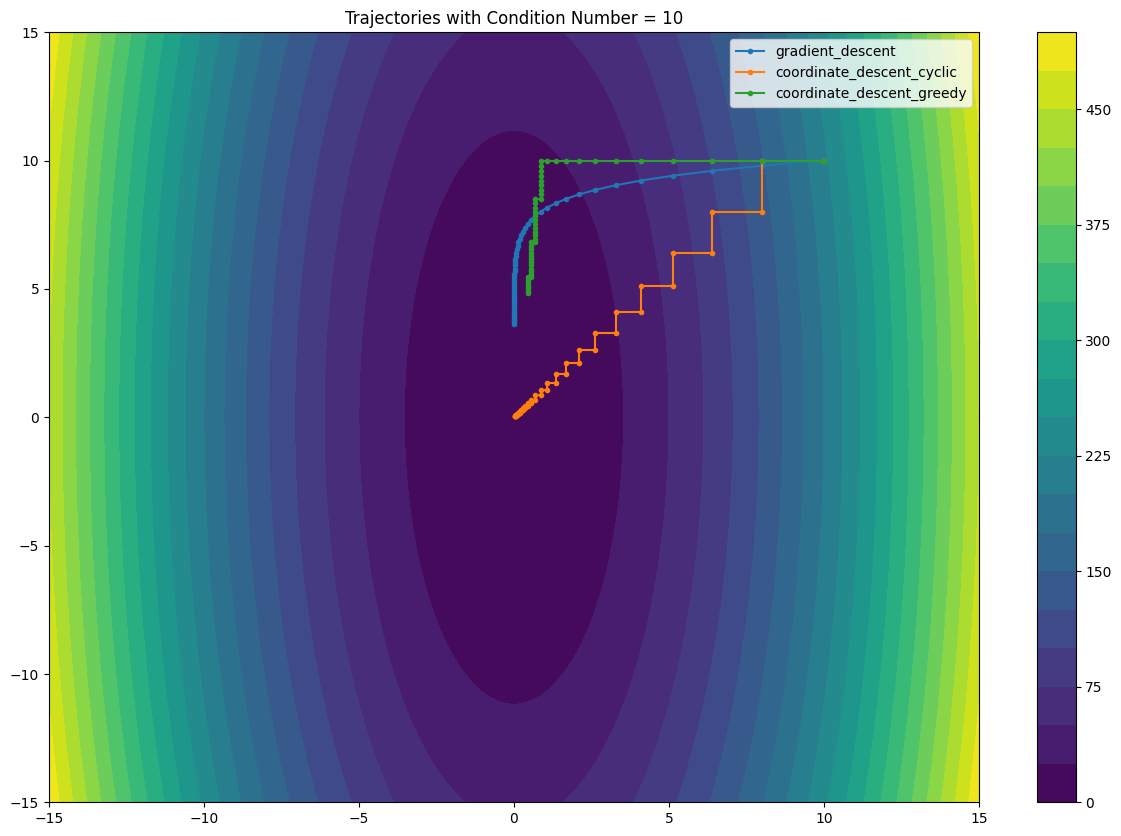

In [21]:

methods = ["gradient_descent", "coordinate_descent_cyclic", "coordinate_descent_greedy"]
condition_numbers = [1, 4, 10]

# Generate contour plots for the quadratic functions
x = np.linspace(-15, 15, 400)
y = np.linspace(-15, 15, 400)
X, Y = np.meshgrid(x, y)

x0 = 10 * np.ones(2)
for condition_number in condition_numbers:
    Z = np.array([[quadratic_conditioned(np.array([xi,yi]), condition_number) for xi in x] for yi in y])

    plt.figure(figsize=(15, 10))
    plt.contourf(X, Y, Z, 20, cmap='viridis')
    plt.colorbar()

    for method in methods:
        _, traj = unconstrained_optimization(quadratic_conditioned, quadratic_conditioned_grad, quadratic_conditioned_hessian, learning_rate = 0.05, num_iterations=50, method = method, x_init = x0, condition_number = condition_number)
        plt.plot(traj[:, 0], traj[:, 1], '-o', label=method, markersize=3)

    plt.title(f"Trajectories with Condition Number = {condition_number}")
    plt.legend()
    plt.show()

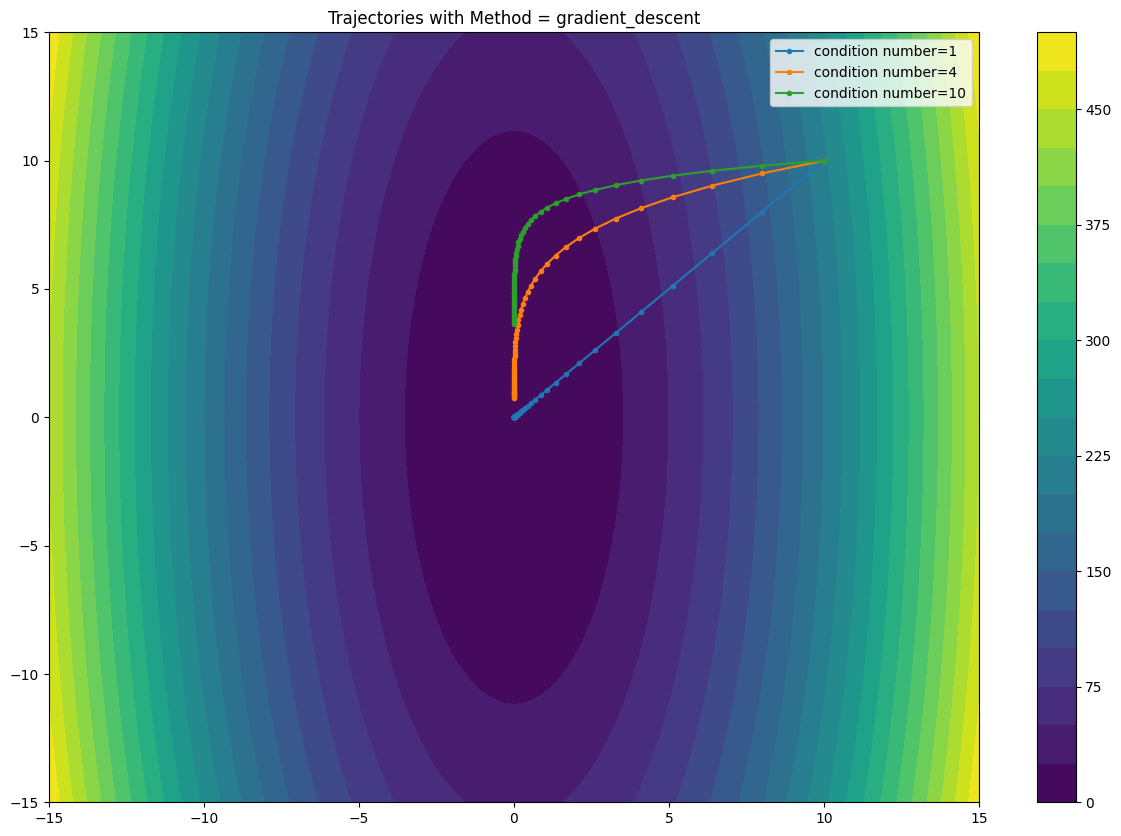

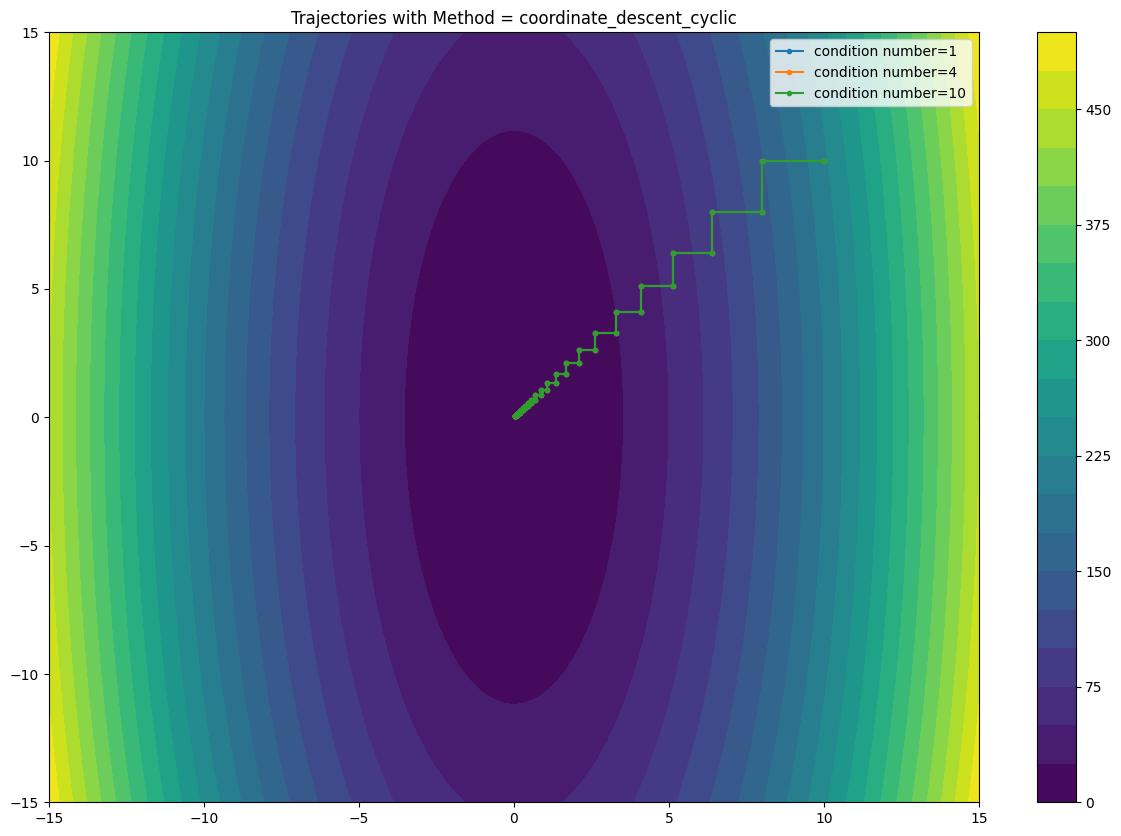

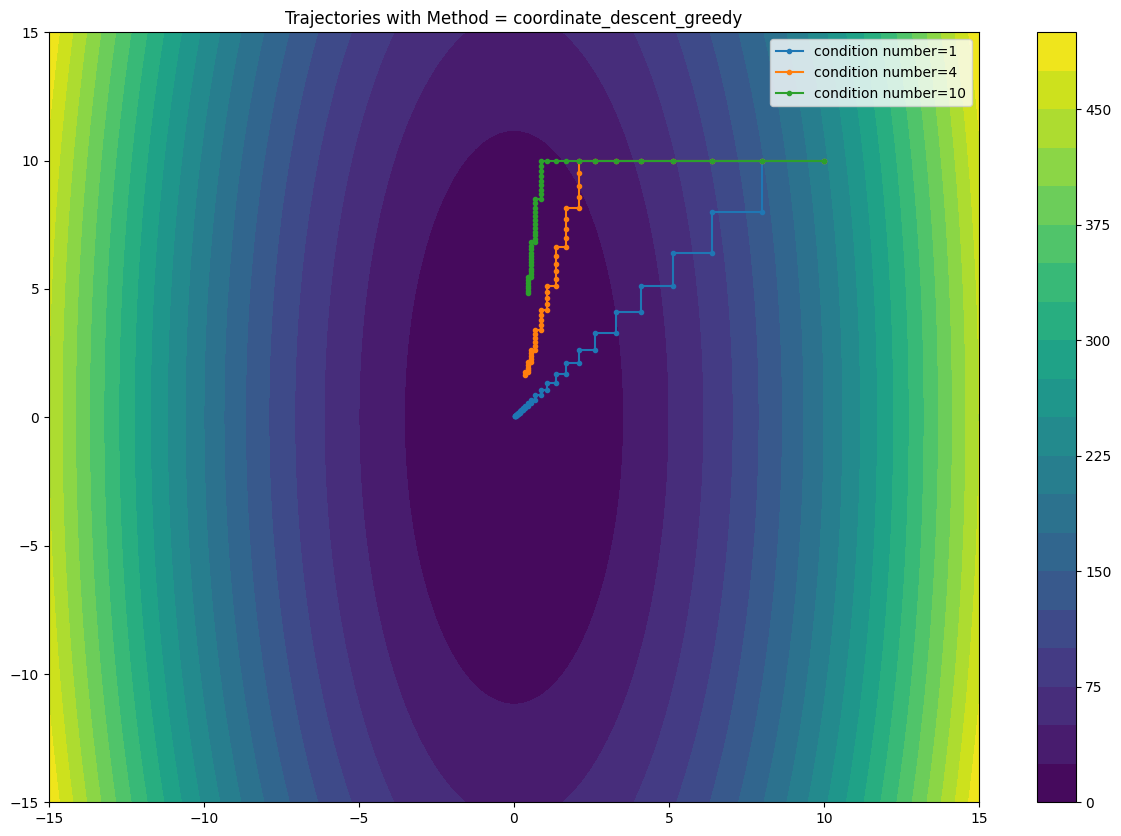

In [22]:
methods = ["gradient_descent", "coordinate_descent_cyclic", "coordinate_descent_greedy"]
condition_numbers = [1, 4, 10]

# Generate contour plots for the quadratic functions
x = np.linspace(-15, 15, 400)
y = np.linspace(-15, 15, 400)
X, Y = np.meshgrid(x, y)

x0 = 10 * np.ones(2)
for method in methods:
    Z = np.array([[quadratic_conditioned(np.array([xi,yi]), condition_number) for xi in x] for yi in y])

    plt.figure(figsize=(15, 10))
    plt.contourf(X, Y, Z, 20, cmap='viridis')
    plt.colorbar()

    for condition_number in condition_numbers:
        _, traj = unconstrained_optimization(quadratic_conditioned, quadratic_conditioned_grad, quadratic_conditioned_hessian, learning_rate = 0.05, num_iterations=50, method = method, x_init = x0, condition_number = condition_number)
        plt.plot(traj[:, 0], traj[:, 1], '-o', label=f"condition number={condition_number}", markersize=3)

    plt.title(f"Trajectories with Method = {method}")
    plt.legend()
    plt.show()

### Note: Cyclic coordinate descent trajectories are the same for all the three cases.

## We further compare GD, coordinate descent, and sign GD on convex quadratic functions with different condition numbers.

We consider minimizing some quadratic functions $f (x, y ) = a\cdot  x  ^2 + b\cdot y ^2$.

In [23]:
import matplotlib.pyplot as plt
import numpy as np

X, Y = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-10, 10, 200))

def plot_gradient_descent(ax, lr, func, dfunc, hessian):
    Z = func(X, Y)
    f = Z[:-1, :-1]
    z_min, z_max = 0, np.abs(f).max()

    c = ax.pcolormesh(X, Y, f, cmap='viridis', vmin=z_min, vmax=z_max)
    ax.axis([X.min(), X.max(), Y.min(), Y.max()])
    fig.colorbar(c, ax=ax)

    x = 8
    y = 8

    xs = [x]
    ys = [y]
    for epoch in range(50):
        df_x, df_y = dfunc(x, y)
        x -= lr * df_x
        y -= lr * df_y
        xs.append(x)
        ys.append(y)
        if func(x, y) < 1E-3:
            break
    cond = np.linalg.cond(hessian(x, y))
    ax.set_title(f"cond #: {cond:.2f}, lr: {lr}, iters: {epoch}")
    ax.plot(xs, ys, 'g-*')
    ax.set_xticks([])
    ax.set_yticks([])



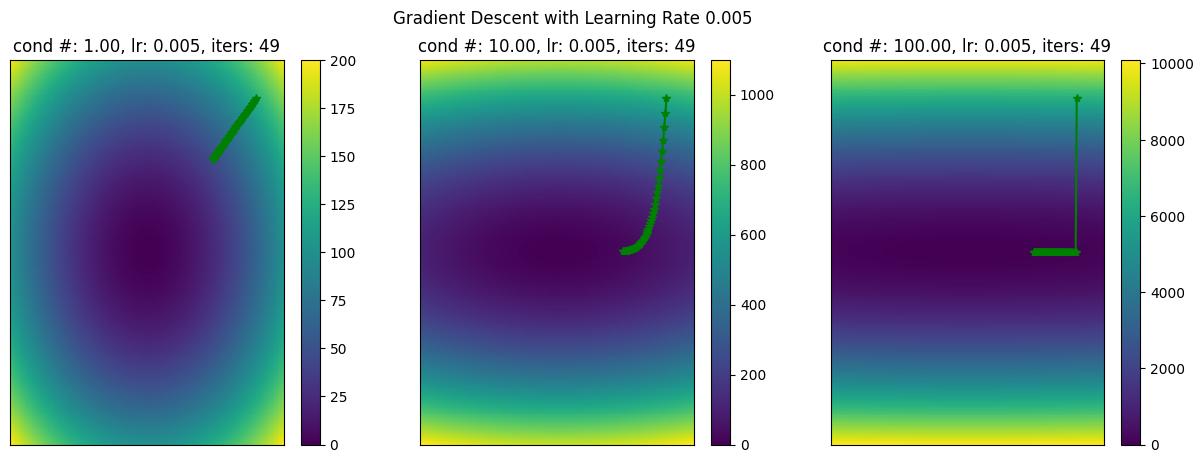

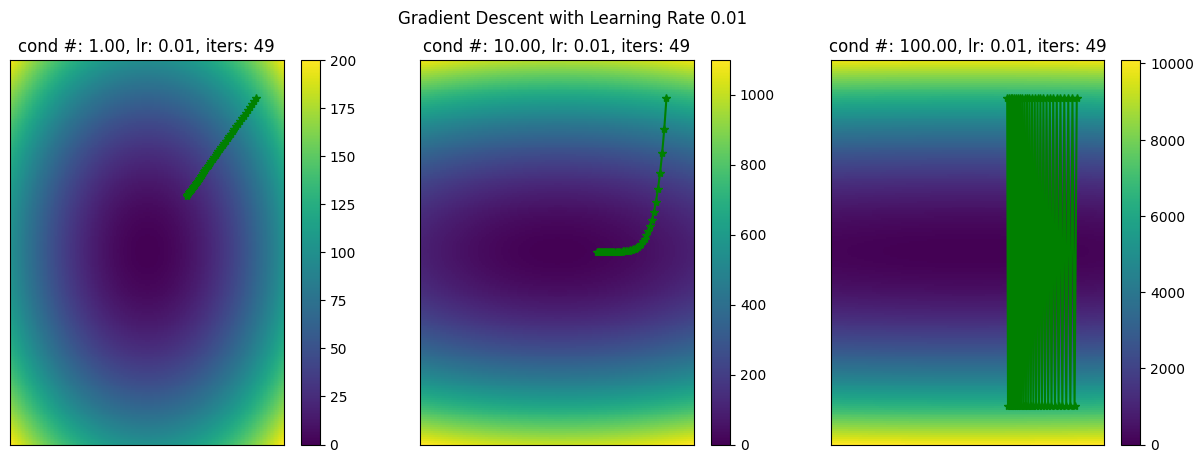

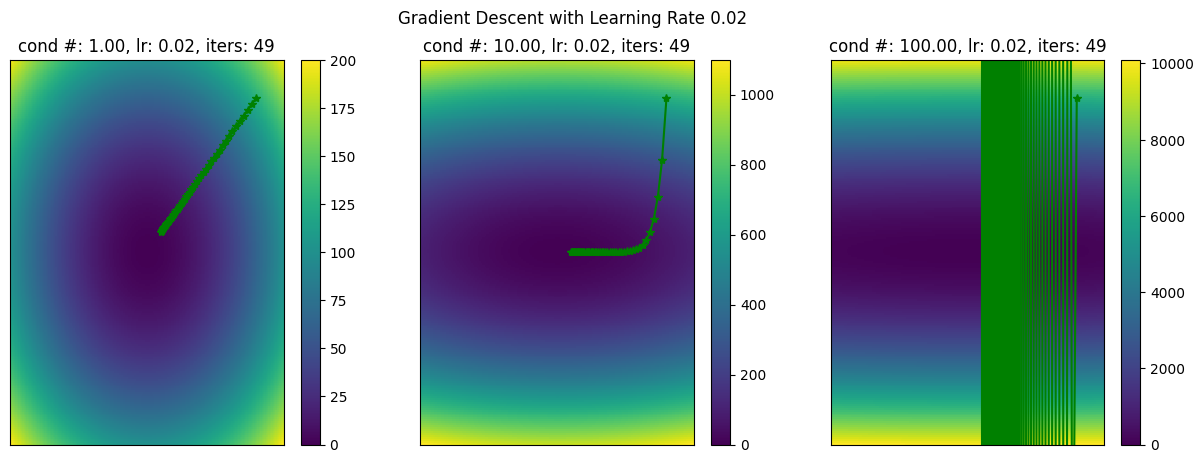

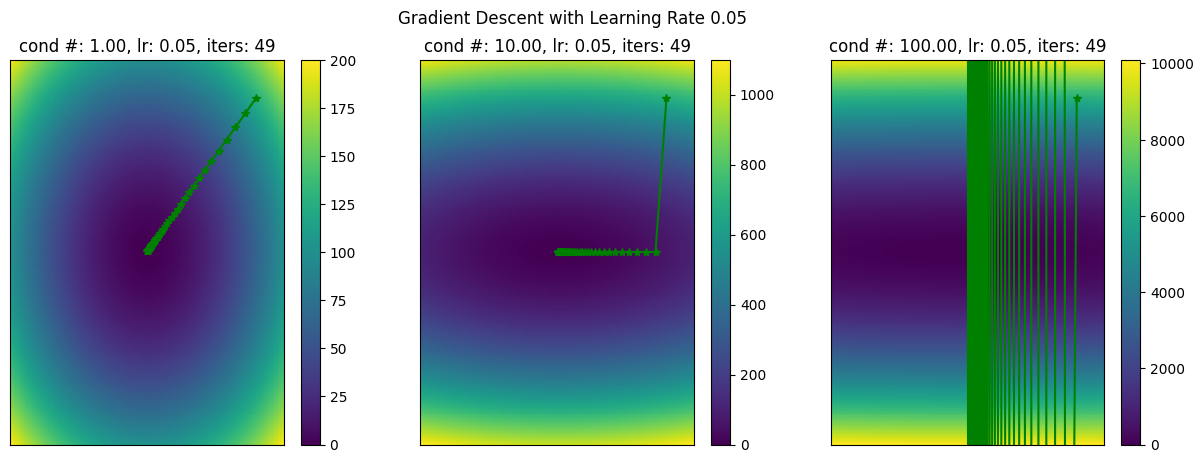

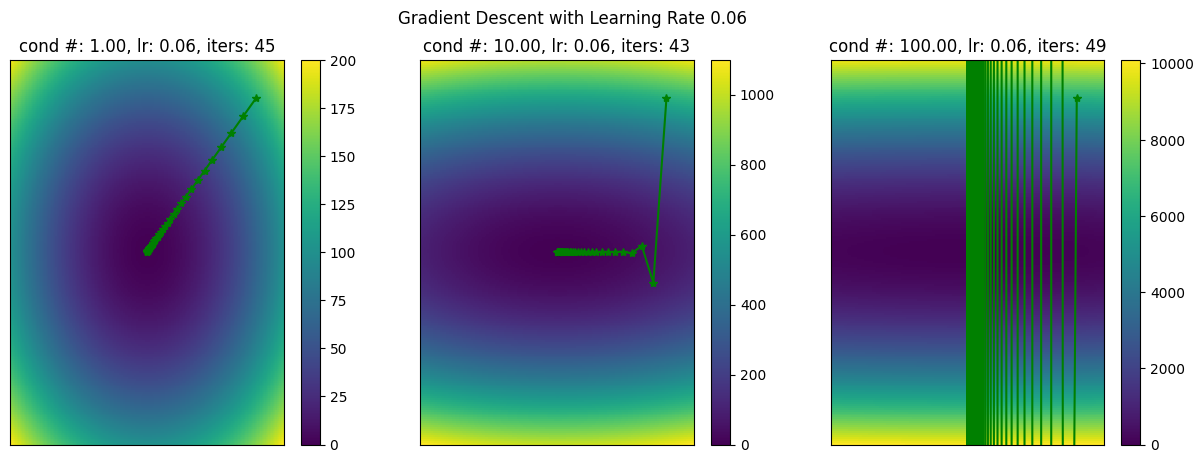

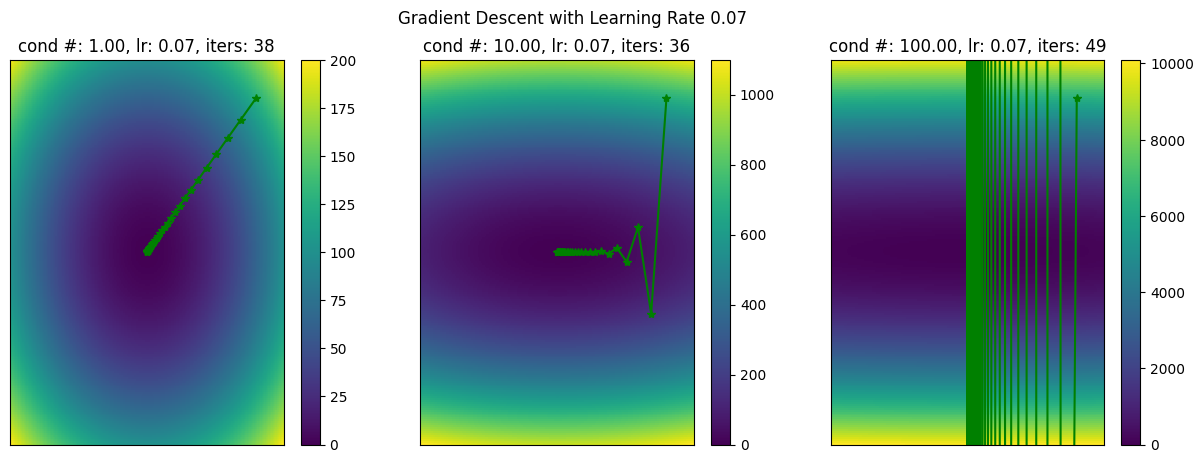

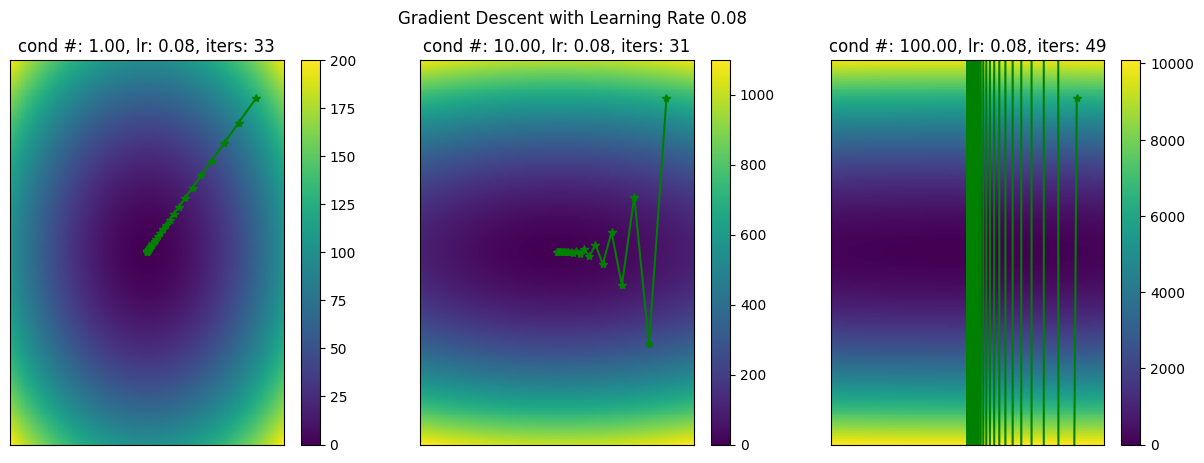

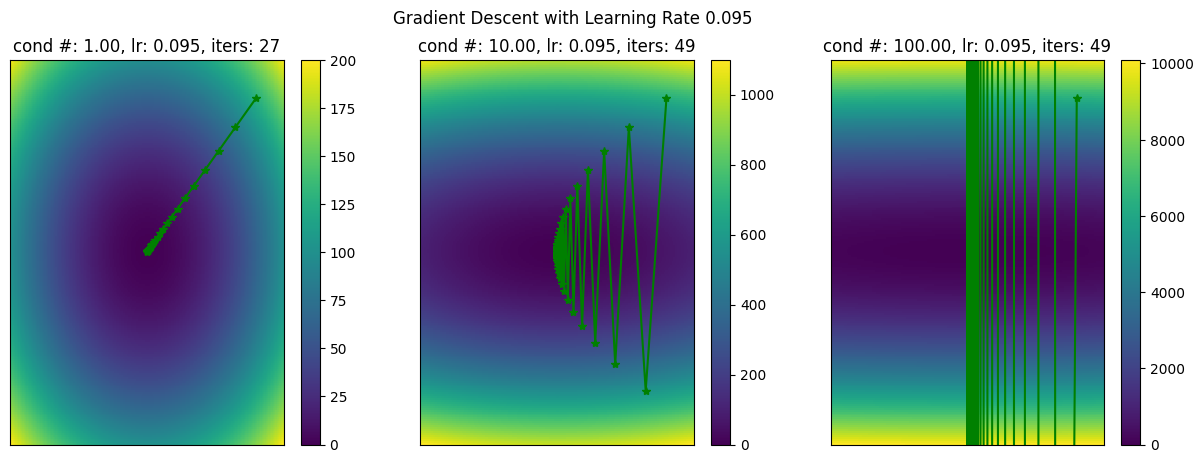

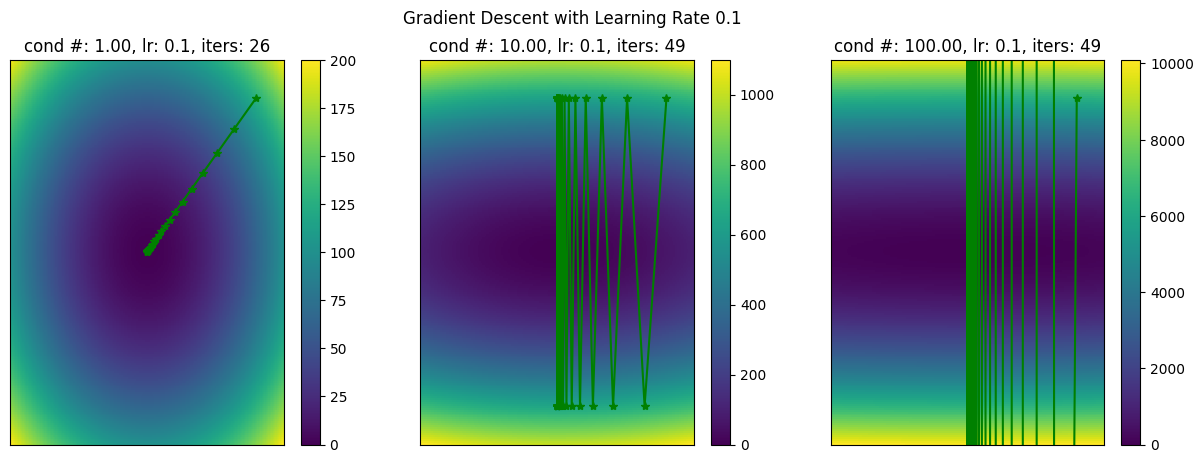

In [24]:
# Define the functions, derivatives, and Hessians
def func1(x, y):
    return x**2 + y**2

def dfunc1(x, y):
    return [2*x, 2*y]

def hessian1(x, y):
    return np.array([[2, 0], [0, 2]])

def func2(x, y):
    return x**2 + 10*y**2

def dfunc2(x, y):
    return [2*x, 20*y]

def hessian2(x, y):
    return np.array([[2, 0], [0, 20]])

def func3(x, y):
    return x**2 + 100*y**2

def dfunc3(x, y):
    return [2*x, 200*y]

def hessian3(x, y):
    return np.array([[2, 0], [0, 200]])

# Learning rates to test
lrs = [0.005, 0.01, 0.02, 0.05, 0.06, 0.07, 0.08, 0.095, 0.1]


for lr in lrs:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    plot_gradient_descent(ax1, lr, func1, dfunc1, hessian1)
    plot_gradient_descent(ax2, lr, func2, dfunc2, hessian2)
    plot_gradient_descent(ax3, lr, func3, dfunc3, hessian3)
    fig.suptitle(f"Gradient Descent with Learning Rate {lr}")
    plt.show()


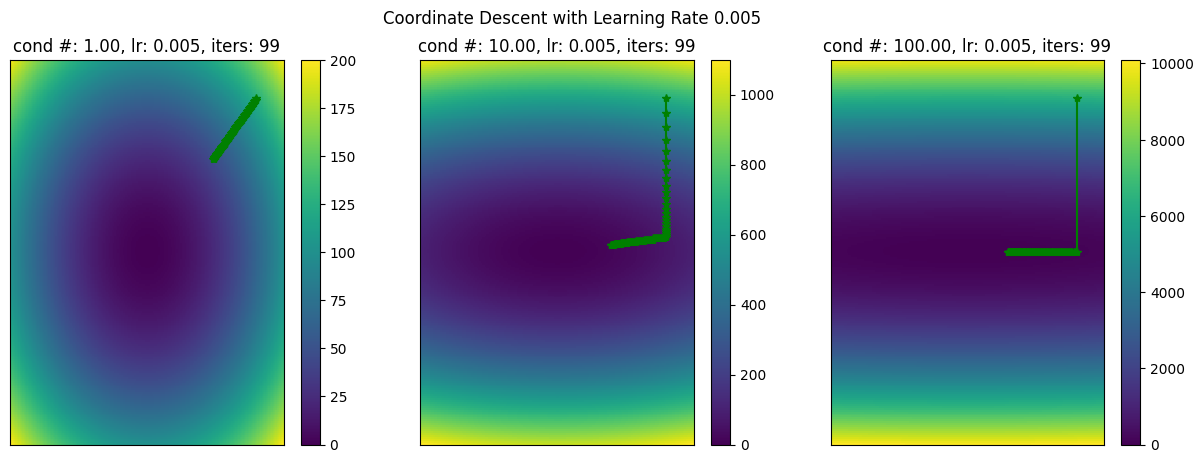

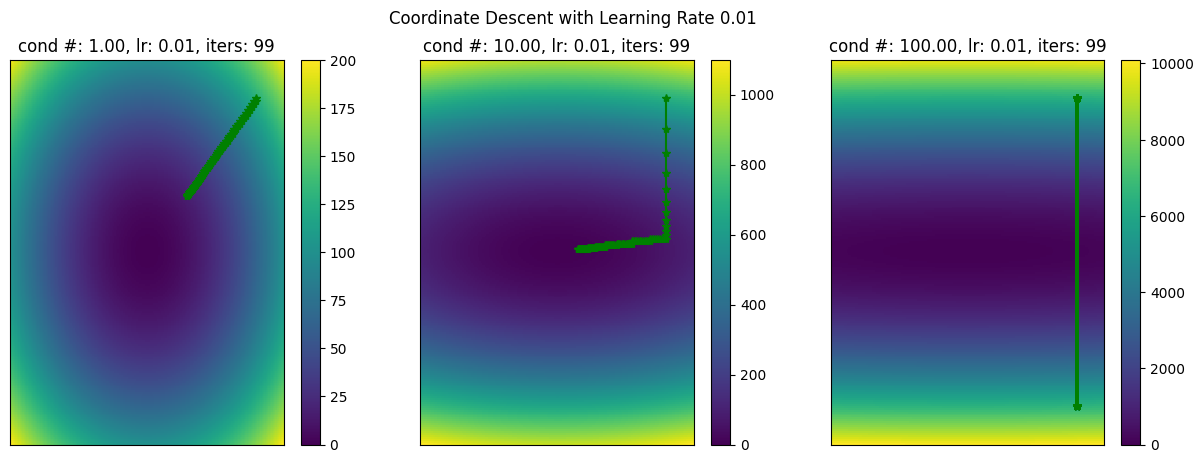

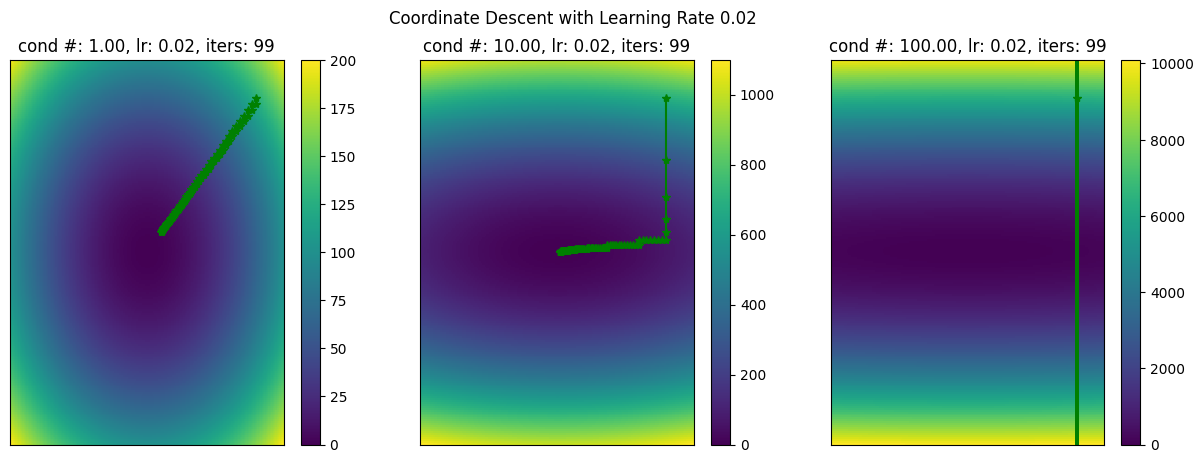

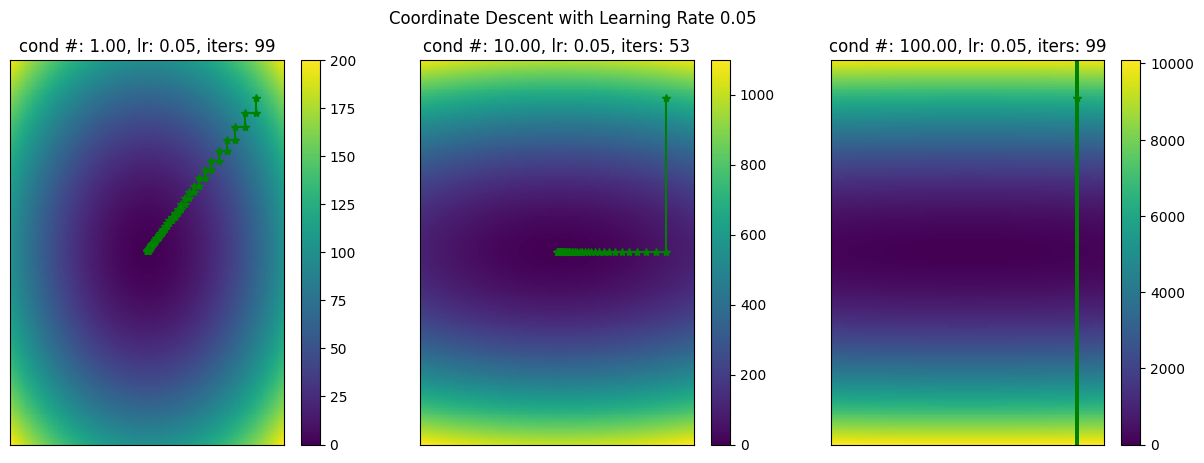

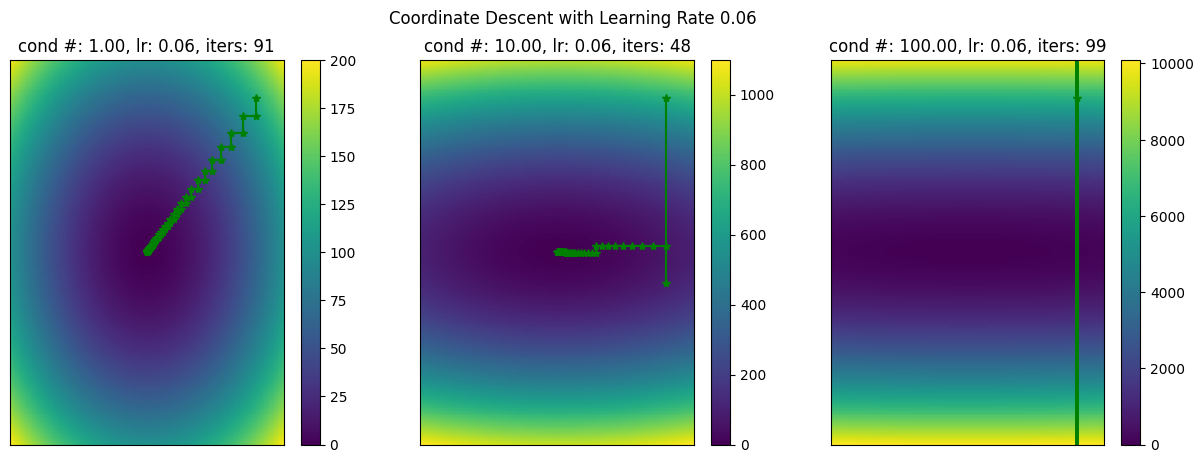

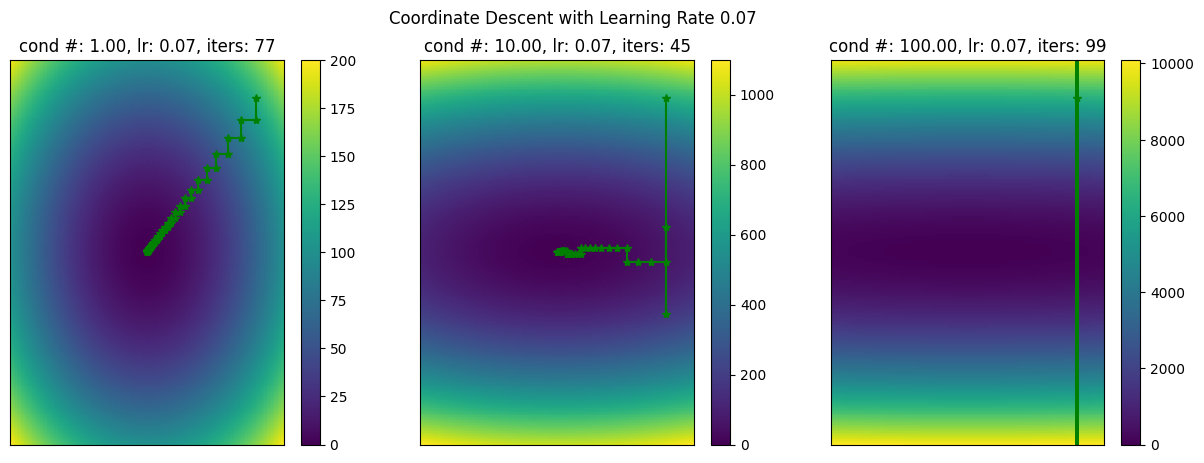

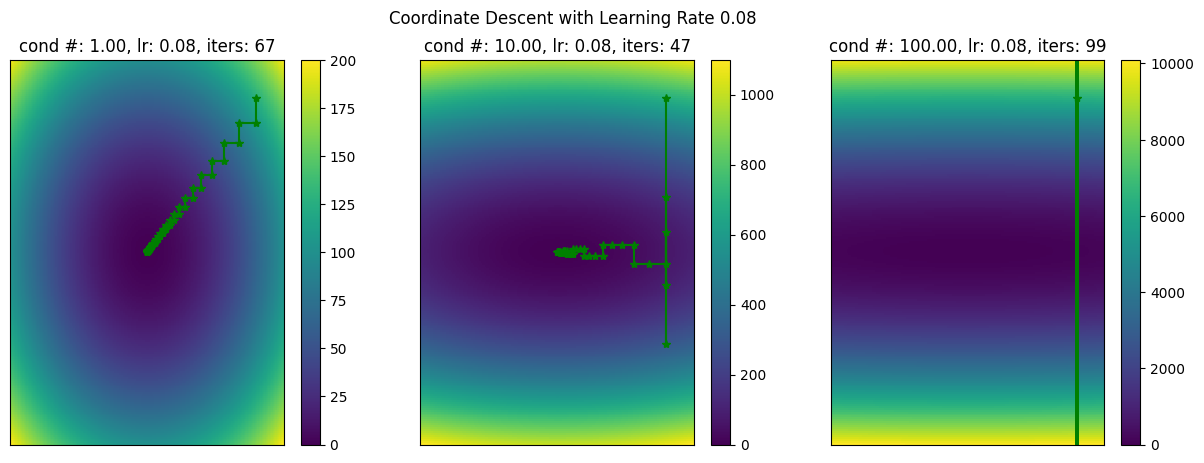

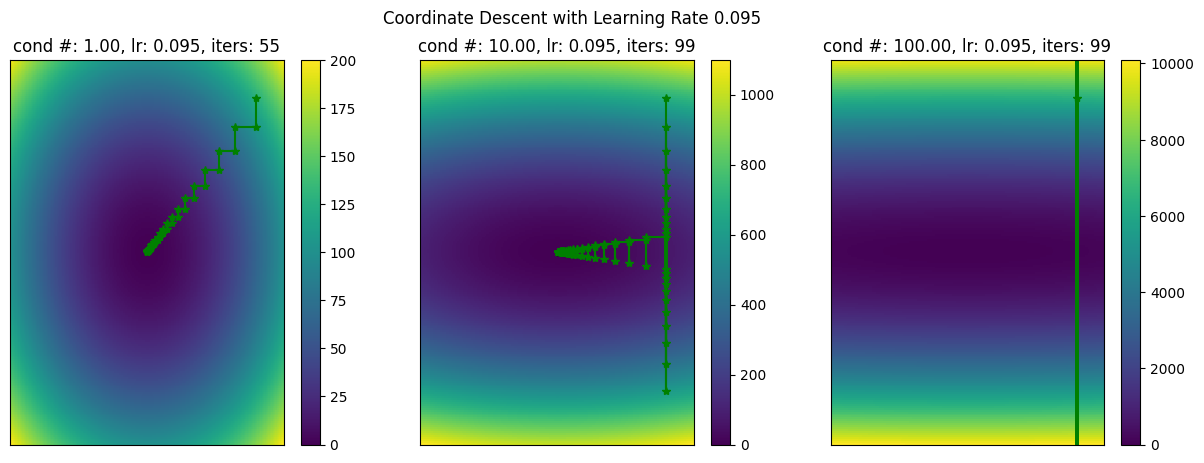

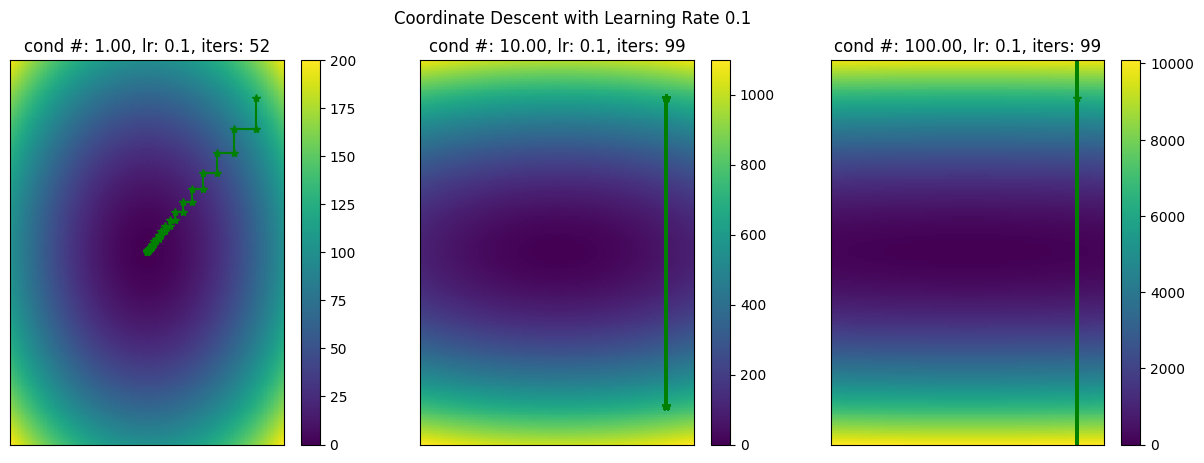

In [25]:
def plot_coordinate_descent(ax, lr, func, dfunc, hessian):
    Z = func(X, Y)
    f = Z[:-1, :-1]
    z_min, z_max = 0, np.abs(f).max()

    c = ax.pcolormesh(X, Y, f, cmap='viridis', vmin=z_min, vmax=z_max)
    ax.axis([X.min(), X.max(), Y.min(), Y.max()])
    fig.colorbar(c, ax=ax)

    x = 8
    y = 8

    xs = [x]
    ys = [y]
    for epoch in range(100):
        df_x, df_y = dfunc(x, y)
        # Greedy index selection: pick the direction with the largest absolute derivative
        if np.abs(df_x) > np.abs(df_y):
            x -= lr * df_x
        else:
            y -= lr * df_y
        xs.append(x)
        ys.append(y)
        if func(x, y) < 1E-3:
            break
    cond = np.linalg.cond(hessian(x, y))
    ax.set_title(f"cond #: {cond:.2f}, lr: {lr}, iters: {epoch}")
    ax.plot(xs, ys, 'g-*')
    ax.set_xticks([])
    ax.set_yticks([])



# Learning rates to test
lrs = [0.005, 0.01, 0.02, 0.05, 0.06, 0.07, 0.08, 0.095, 0.1]


for lr in lrs:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    plot_coordinate_descent(ax1, lr, func1, dfunc1, hessian1)
    plot_coordinate_descent(ax2, lr, func2, dfunc2, hessian2)
    plot_coordinate_descent(ax3, lr, func3, dfunc3, hessian3)
    fig.suptitle(f"Coordinate Descent with Learning Rate {lr}")
    plt.show()





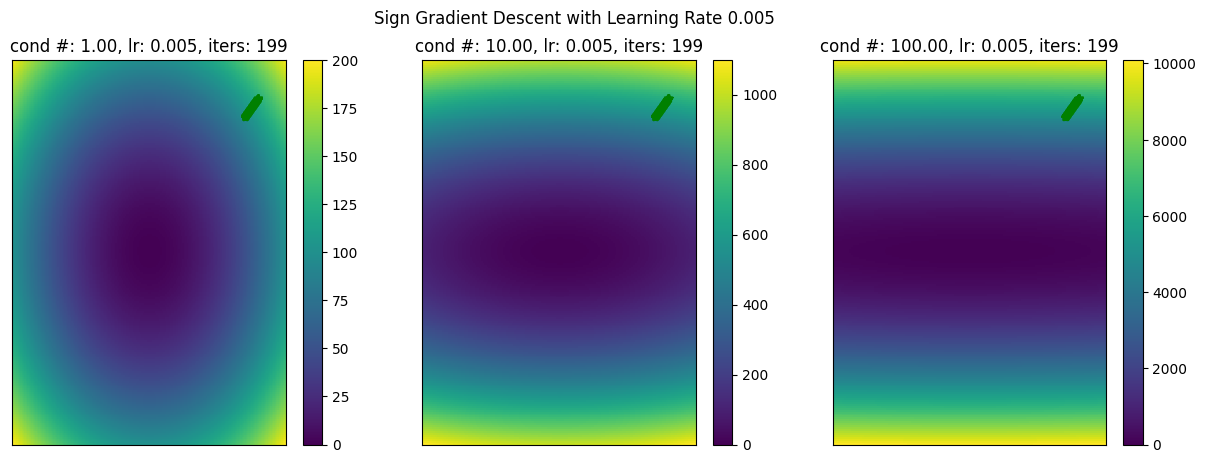

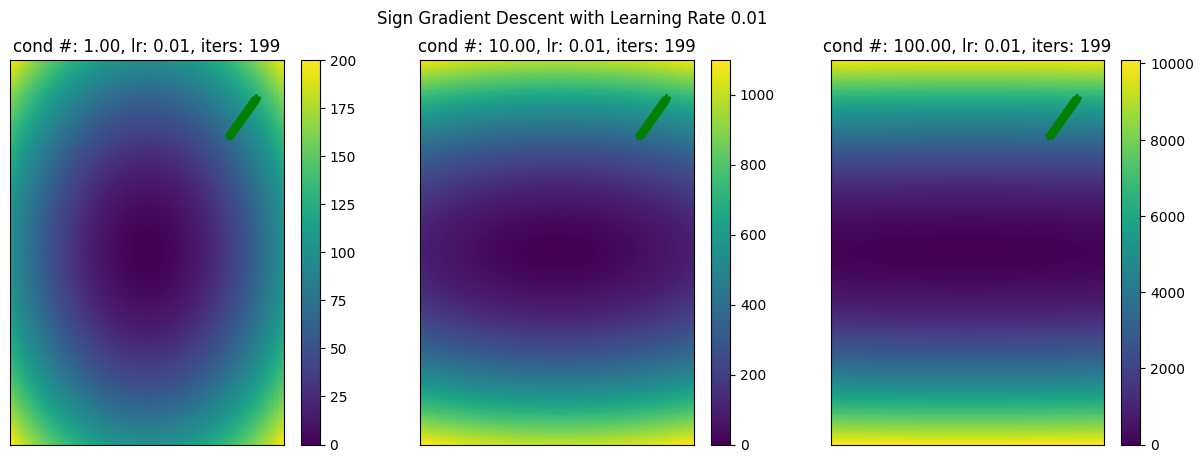

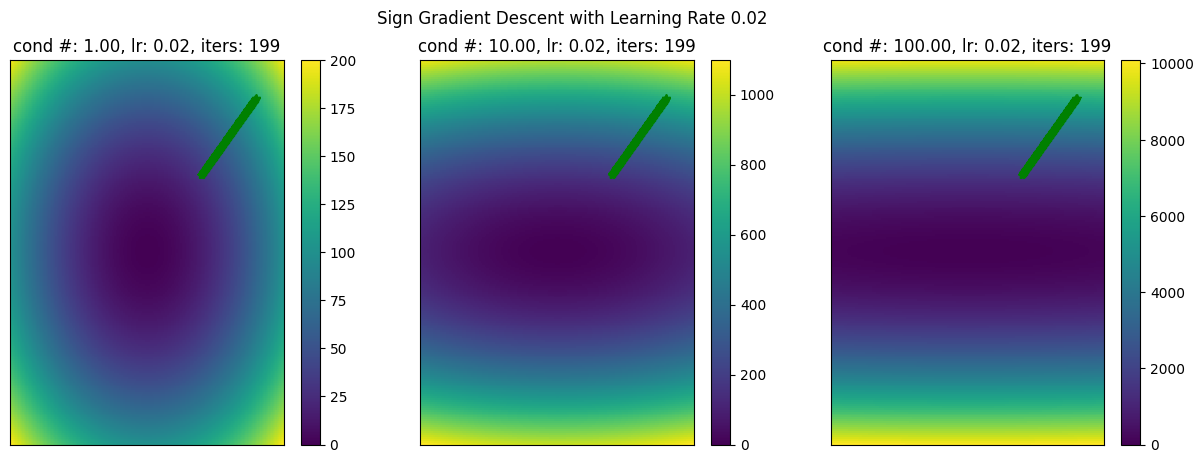

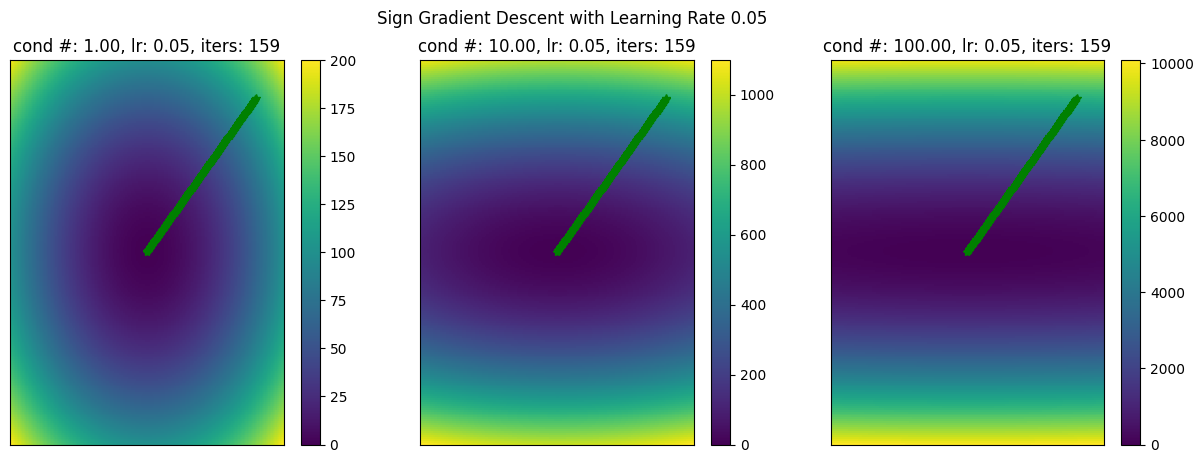

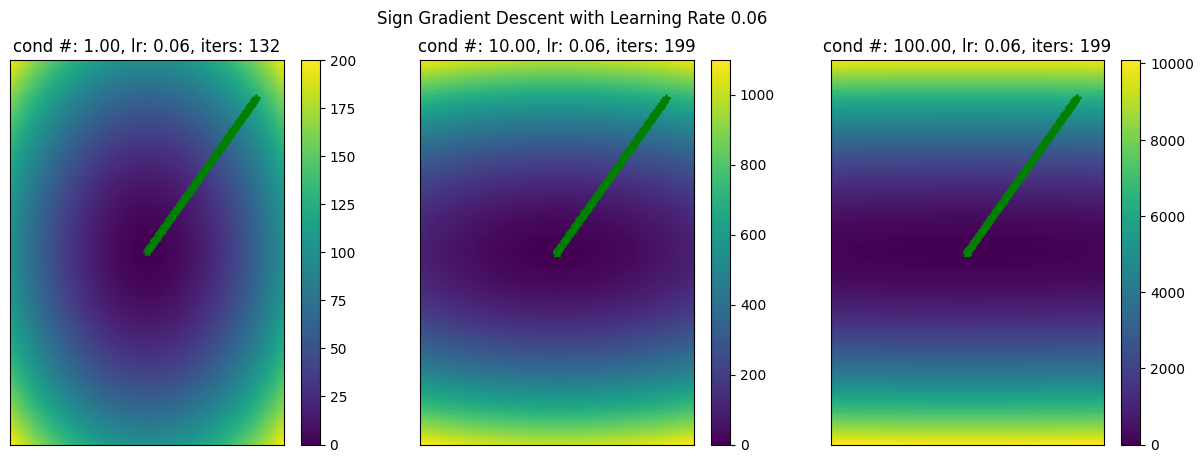

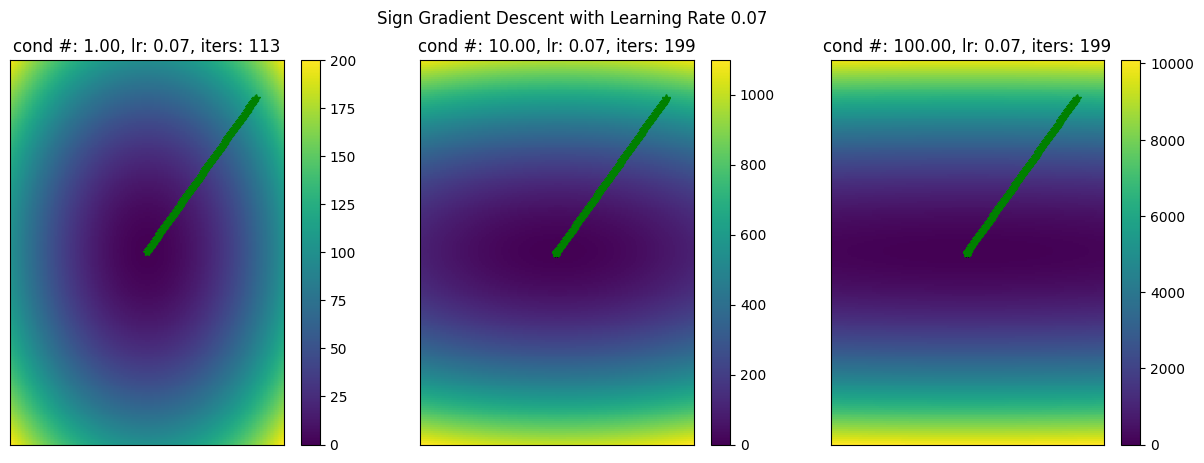

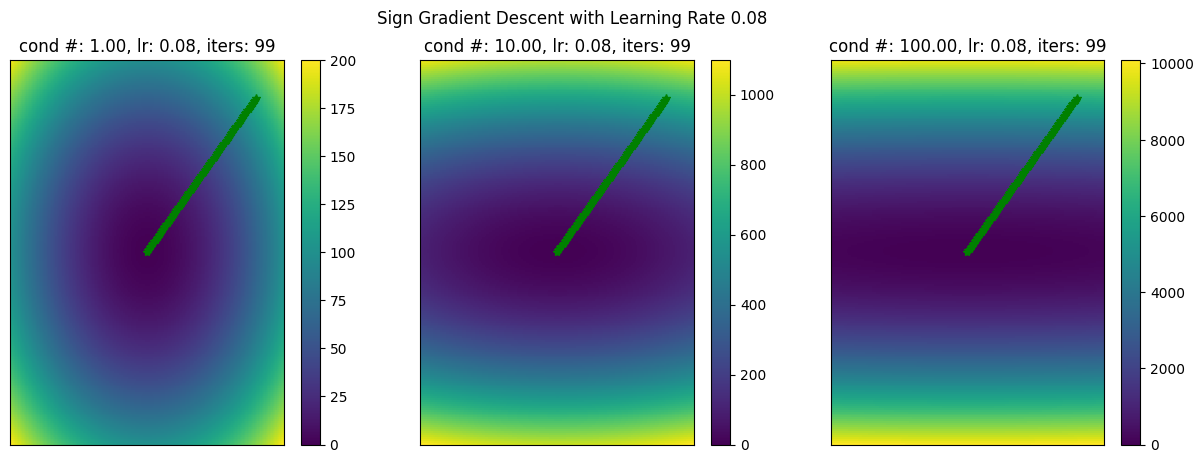

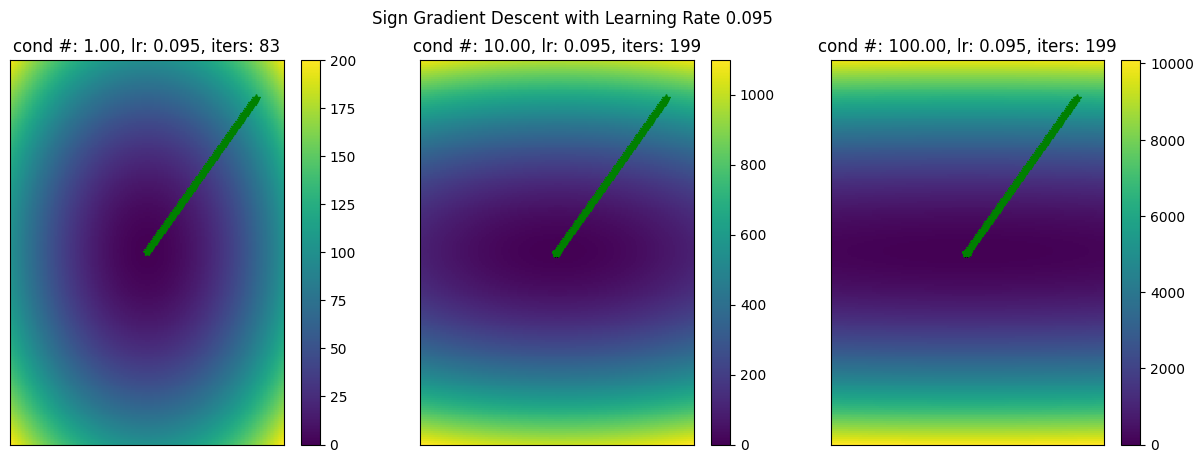

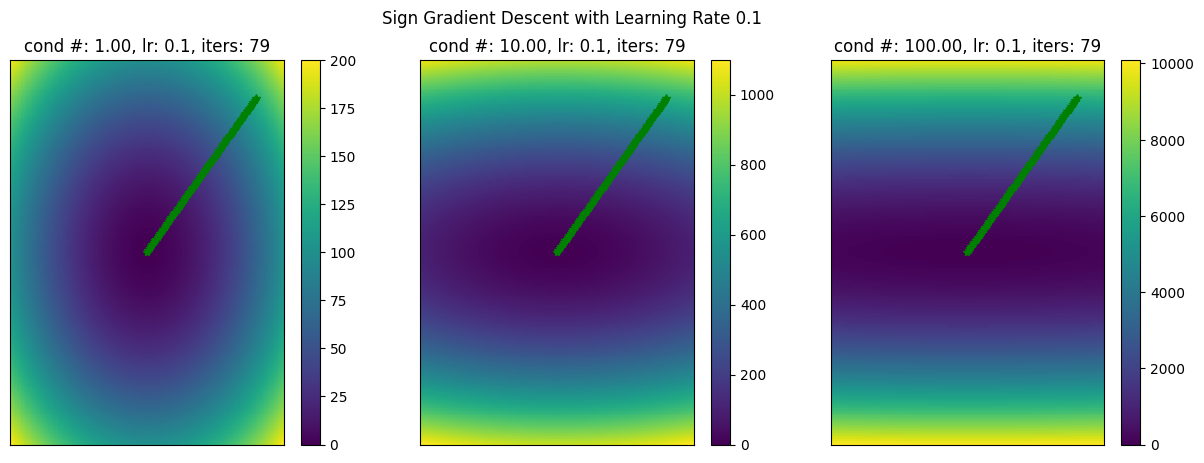

In [26]:
def plot_sign_gradient_descent(ax, lr, func, dfunc, hessian):
    Z = func(X, Y)
    f = Z[:-1, :-1]
    z_min, z_max = 0, np.abs(f).max()

    c = ax.pcolormesh(X, Y, f, cmap='viridis', vmin=z_min, vmax=z_max)
    ax.axis([X.min(), X.max(), Y.min(), Y.max()])
    fig.colorbar(c, ax=ax)

    x = 8
    y = 8

    xs = [x]
    ys = [y]
    for epoch in range(200):
        df_x, df_y = dfunc(x, y)
        sign_dfx = np.sign(df_x)
        sign_dfy = np.sign(df_y)

        x -= lr * sign_dfx
        y -= lr * sign_dfy
        xs.append(x)
        ys.append(y)
        if func(x, y) < 1E-3:
            break
    cond = np.linalg.cond(hessian(x, y))
    ax.set_title(f"cond #: {cond:.2f}, lr: {lr}, iters: {epoch}")
    ax.plot(xs, ys, 'g-*')
    ax.set_xticks([])
    ax.set_yticks([])


for lr in lrs:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    plot_sign_gradient_descent(ax1, lr, func1, dfunc1, hessian1)
    plot_sign_gradient_descent(ax2, lr, func2, dfunc2, hessian2)
    plot_sign_gradient_descent(ax3, lr, func3, dfunc3, hessian3)
    fig.suptitle(f"Sign Gradient Descent with Learning Rate {lr}")
    plt.show()


## Non-Convex Test Functions: The Beale Function

So far we have studied quadratic (convex) objectives. In practice, many optimization problems -- especially in machine learning -- are **non-convex**, meaning they may have multiple local minima, saddle points, and flat regions. To stress-test optimization algorithms, researchers use a collection of standard non-convex benchmark functions.

### Beale Function

The Beale function is defined as

$$
f(x_1, x_2) = \bigl(1.5 - x_1 + x_1 x_2\bigr)^2 + \bigl(2.25 - x_1 + x_1 x_2^2\bigr)^2 + \bigl(2.625 - x_1 + x_1 x_2^3\bigr)^2.
$$

**Properties:**

1. **Non-convexity:** The function has a complicated landscape with steep ridges and flat valleys.
2. **Global minimizer:** $(x_1^*, x_2^*) = (3,\, 0.5)$ with $f(3, 0.5) = 0$.
3. **Multiple local minima:** Algorithms that rely only on local gradient information can easily get trapped far from the global minimum.

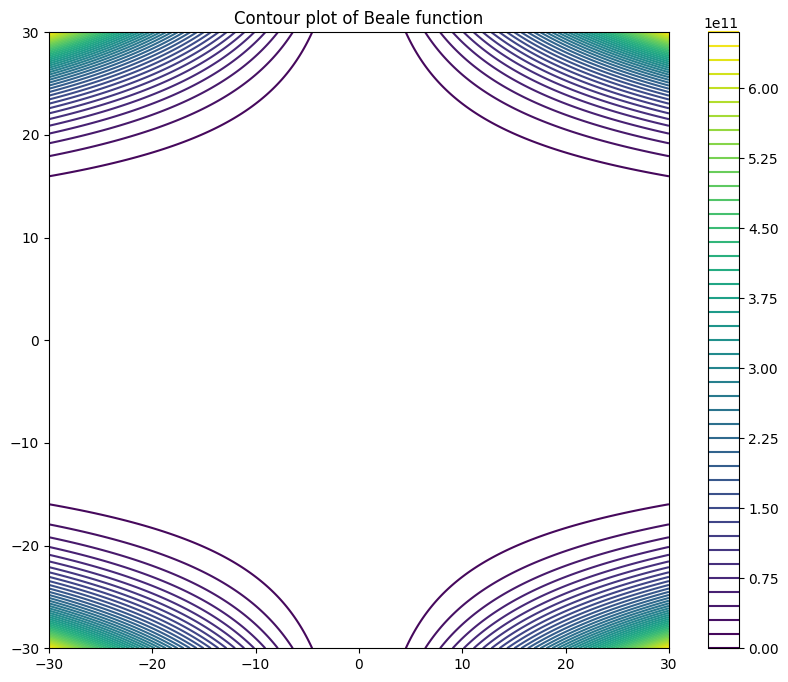

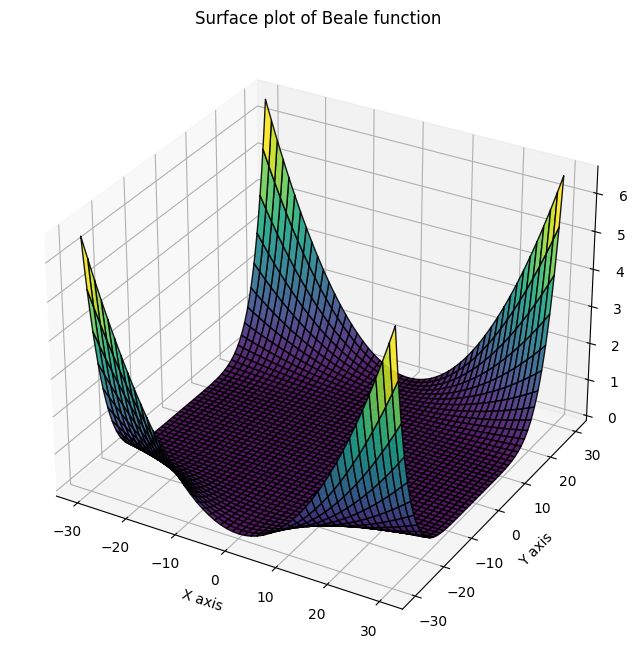

In [27]:
def beale(x):
    x1, x2 = x
    return (1.5 - x1 + x1*x2)**2 + (2.25 - x1 + x1*x2**2)**2 + (2.625 - x1 + x1*x2**3)**2

def beale_grad(x):
    x1, x2 = x
    dfdx1 = 2.0 * ( (1.5 - x1 + x1*x2)*(x2-1) + (2.25 - x1 + x1*x2**2)*(x2**2-1) + (2.625 - x1 + x1*x2**3)*(x2**3-1) )
    dfdx2 = 2.0 * ( (1.5 - x1 + x1*x2)*x1 + (2.25 - x1 + x1*x2**2)*2*x1*x2 + (2.625 - x1 + x1*x2**3)*3*x1*x2**2 )
    return np.array([dfdx1, dfdx2])

def beale_hessian(x):
    x1, x2 = x
    h11 = 2 * ((x2 - 1)**2 + (x2**2 - 1)**2 + (x2**3 - 1)**2)
    h12 = 2 * ((x2 - 1) * x1 + 2 * (x2**2 - 1) * x1 * x2 + 3 * (x2**3 - 1) * x1 * x2**2)
    h21 = h12  # Hessian is symmetric
    h22 = 2 * (x1**2 + 4 * x1**2 * x2**2 + 9 * x1**2 * x2**4)
    return np.array([[h11, h12], [h21, h22]])



# Generate grid for plotting
x_values = np.linspace(-30, 30, 400)
y_values = np.linspace(-30, 30, 400)
X, Y = np.meshgrid(x_values, y_values)

# Beale function contour
Z_beale = np.array([beale(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z_beale = Z_beale.reshape(X.shape)

plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z_beale, 50, cmap='viridis')
plt.title('Contour plot of Beale function')
plt.colorbar()
plt.show()



# Plotting the surface of the Beale function
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z_beale, cmap='viridis', alpha=0.9, edgecolor='k')
ax.set_title('Surface plot of Beale function')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Beale function value')

plt.show()


In [28]:

import numpy as np
import matplotlib.pyplot as plt

methods = ["gradient_descent", "coordinate_descent_cyclic", "coordinate_descent_greedy",  "heavy_ball", "adam", "adagrad", "rmsprop" ]
learning_rates = [0.0005, 0.001, 0.002, 0.01, 0.05]
# methods = ["gradient_descent", "heavy_ball", "adam", "adagrad", "rmsprop"]
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_values, y_values)
Z = np.array([beale(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = Z.reshape(X.shape)

# Number of rows is the number of methods, and number of columns is the number of learning rates
fig, axes = plt.subplots(len(methods), len(learning_rates), figsize=(20, 30))

# Iterate over methods and learning rates to populate the grid
for method_idx, method in enumerate(methods):
    for lr_idx, lr in enumerate(learning_rates):
        ax = axes[method_idx, lr_idx]

        # Generate the contour plot for the Rosenbrock function
        ax.contour(X, Y, Z, 50, cmap='viridis')

        # Perform optimization using the specified method and learning rate
        final_iterate, traj = unconstrained_optimization(beale, beale_grad, beale_hessian, learning_rate=lr, num_iterations=500, method=method, x_init=np.array([-1.5, 2]))
        final_value = beale(final_iterate)
        print(f"Method {method} with learning rate {lr}, the last iterate is {final_iterate}, function value is {final_value:.6f}")

        # Plot the trajectory with gradually changing transparency
        for i in range(len(traj) - 1):
            alpha_value = min(0.8 * (i / len(traj)) + 0.2, 1)  # Keeping alpha within the range [0, 1]
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], '-o', color='blue', alpha=alpha_value, markersize=3)

        # Highlight the end point
        ax.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=5)

        # Set the title for each subplot indicating method and learning rate
        ax.set_title(f"{method}, LR={lr}")

# Adjust layout for clarity
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["gradient_descent", "coordinate_descent_cyclic", "coordinate_descent_greedy",  "heavy_ball", "adam", "adagrad", "rmsprop" ]
learning_rates = [0.0005, 0.001, 0.002, 0.01, 0.05]
# methods = ["gradient_descent", "heavy_ball", "adam", "adagrad", "rmsprop"]
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_values, y_values)
Z = np.array([beale(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = Z.reshape(X.shape)

# Number of rows is the number of methods, and number of columns is the number of learning rates
fig, axes = plt.subplots(len(methods), len(learning_rates), figsize=(20, 30))

# Iterate over methods and learning rates to populate the grid
for method_idx, method in enumerate(methods):
    for lr_idx, lr in enumerate(learning_rates):
        ax = axes[method_idx, lr_idx]

        # Generate the contour plot for the Rosenbrock function
        ax.contour(X, Y, Z, 50, cmap='viridis')

        # Perform optimization using the specified method and learning rate
        final_iterate, traj = unconstrained_optimization(beale, beale_grad, beale_hessian, learning_rate=lr, num_iterations=1000, method=method, x_init=np.array([-1.5, 2]))
        final_value = beale(final_iterate)
        print(f"Method {method} with learning rate {lr}, the last iterate is {final_iterate}, function value is {final_value:.6f}")

        # Plot the trajectory with gradually changing transparency
        for i in range(len(traj) - 1):
            alpha_value = min(0.8 * (i / len(traj)) + 0.2, 1)  # Keeping alpha within the range [0, 1]
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], '-o', color='blue', alpha=alpha_value, markersize=3)

        # Highlight the end point
        ax.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=5)

        # Set the title for each subplot indicating method and learning rate
        ax.set_title(f"{method}, LR={lr}")

# Adjust layout for clarity
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

<ipython-input-11-51578b1f6f37>:7: RuntimeWarning: overflow encountered in scalar multiply
  dfdx1 = 2.0 * ( (1.5 - x1 + x1*x2)*(x2-1) + (2.25 - x1 + x1*x2**2)*(x2**2-1) + (2.625 - x1 + x1*x2**3)*(x2**3-1) )
<ipython-input-11-51578b1f6f37>:8: RuntimeWarning: overflow encountered in scalar multiply
  dfdx2 = 2.0 * ( (1.5 - x1 + x1*x2)*x1 + (2.25 - x1 + x1*x2**2)*2*x1*x2 + (2.625 - x1 + x1*x2**3)*3*x1*x2**2 )
<ipython-input-11-51578b1f6f37>:7: RuntimeWarning: invalid value encountered in scalar add
  dfdx1 = 2.0 * ( (1.5 - x1 + x1*x2)*(x2-1) + (2.25 - x1 + x1*x2**2)*(x2**2-1) + (2.625 - x1 + x1*x2**3)*(x2**3-1) )
<ipython-input-11-51578b1f6f37>:8: RuntimeWarning: invalid value encountered in scalar add
  dfdx2 = 2.0 * ( (1.5 - x1 + x1*x2)*x1 + (2.25 - x1 + x1*x2**2)*2*x1*x2 + (2.625 - x1 + x1*x2**3)*3*x1*x2**2 )


Method gradient_descent with learning rate 0.05, the last iterate is [nan nan], function value is nan
Method gradient_descent with learning rate 0.1, the last iterate is [nan nan], function value is nan
Method gradient_descent with learning rate 0.3, the last iterate is [nan nan], function value is nan


LinAlgError: Singular matrix

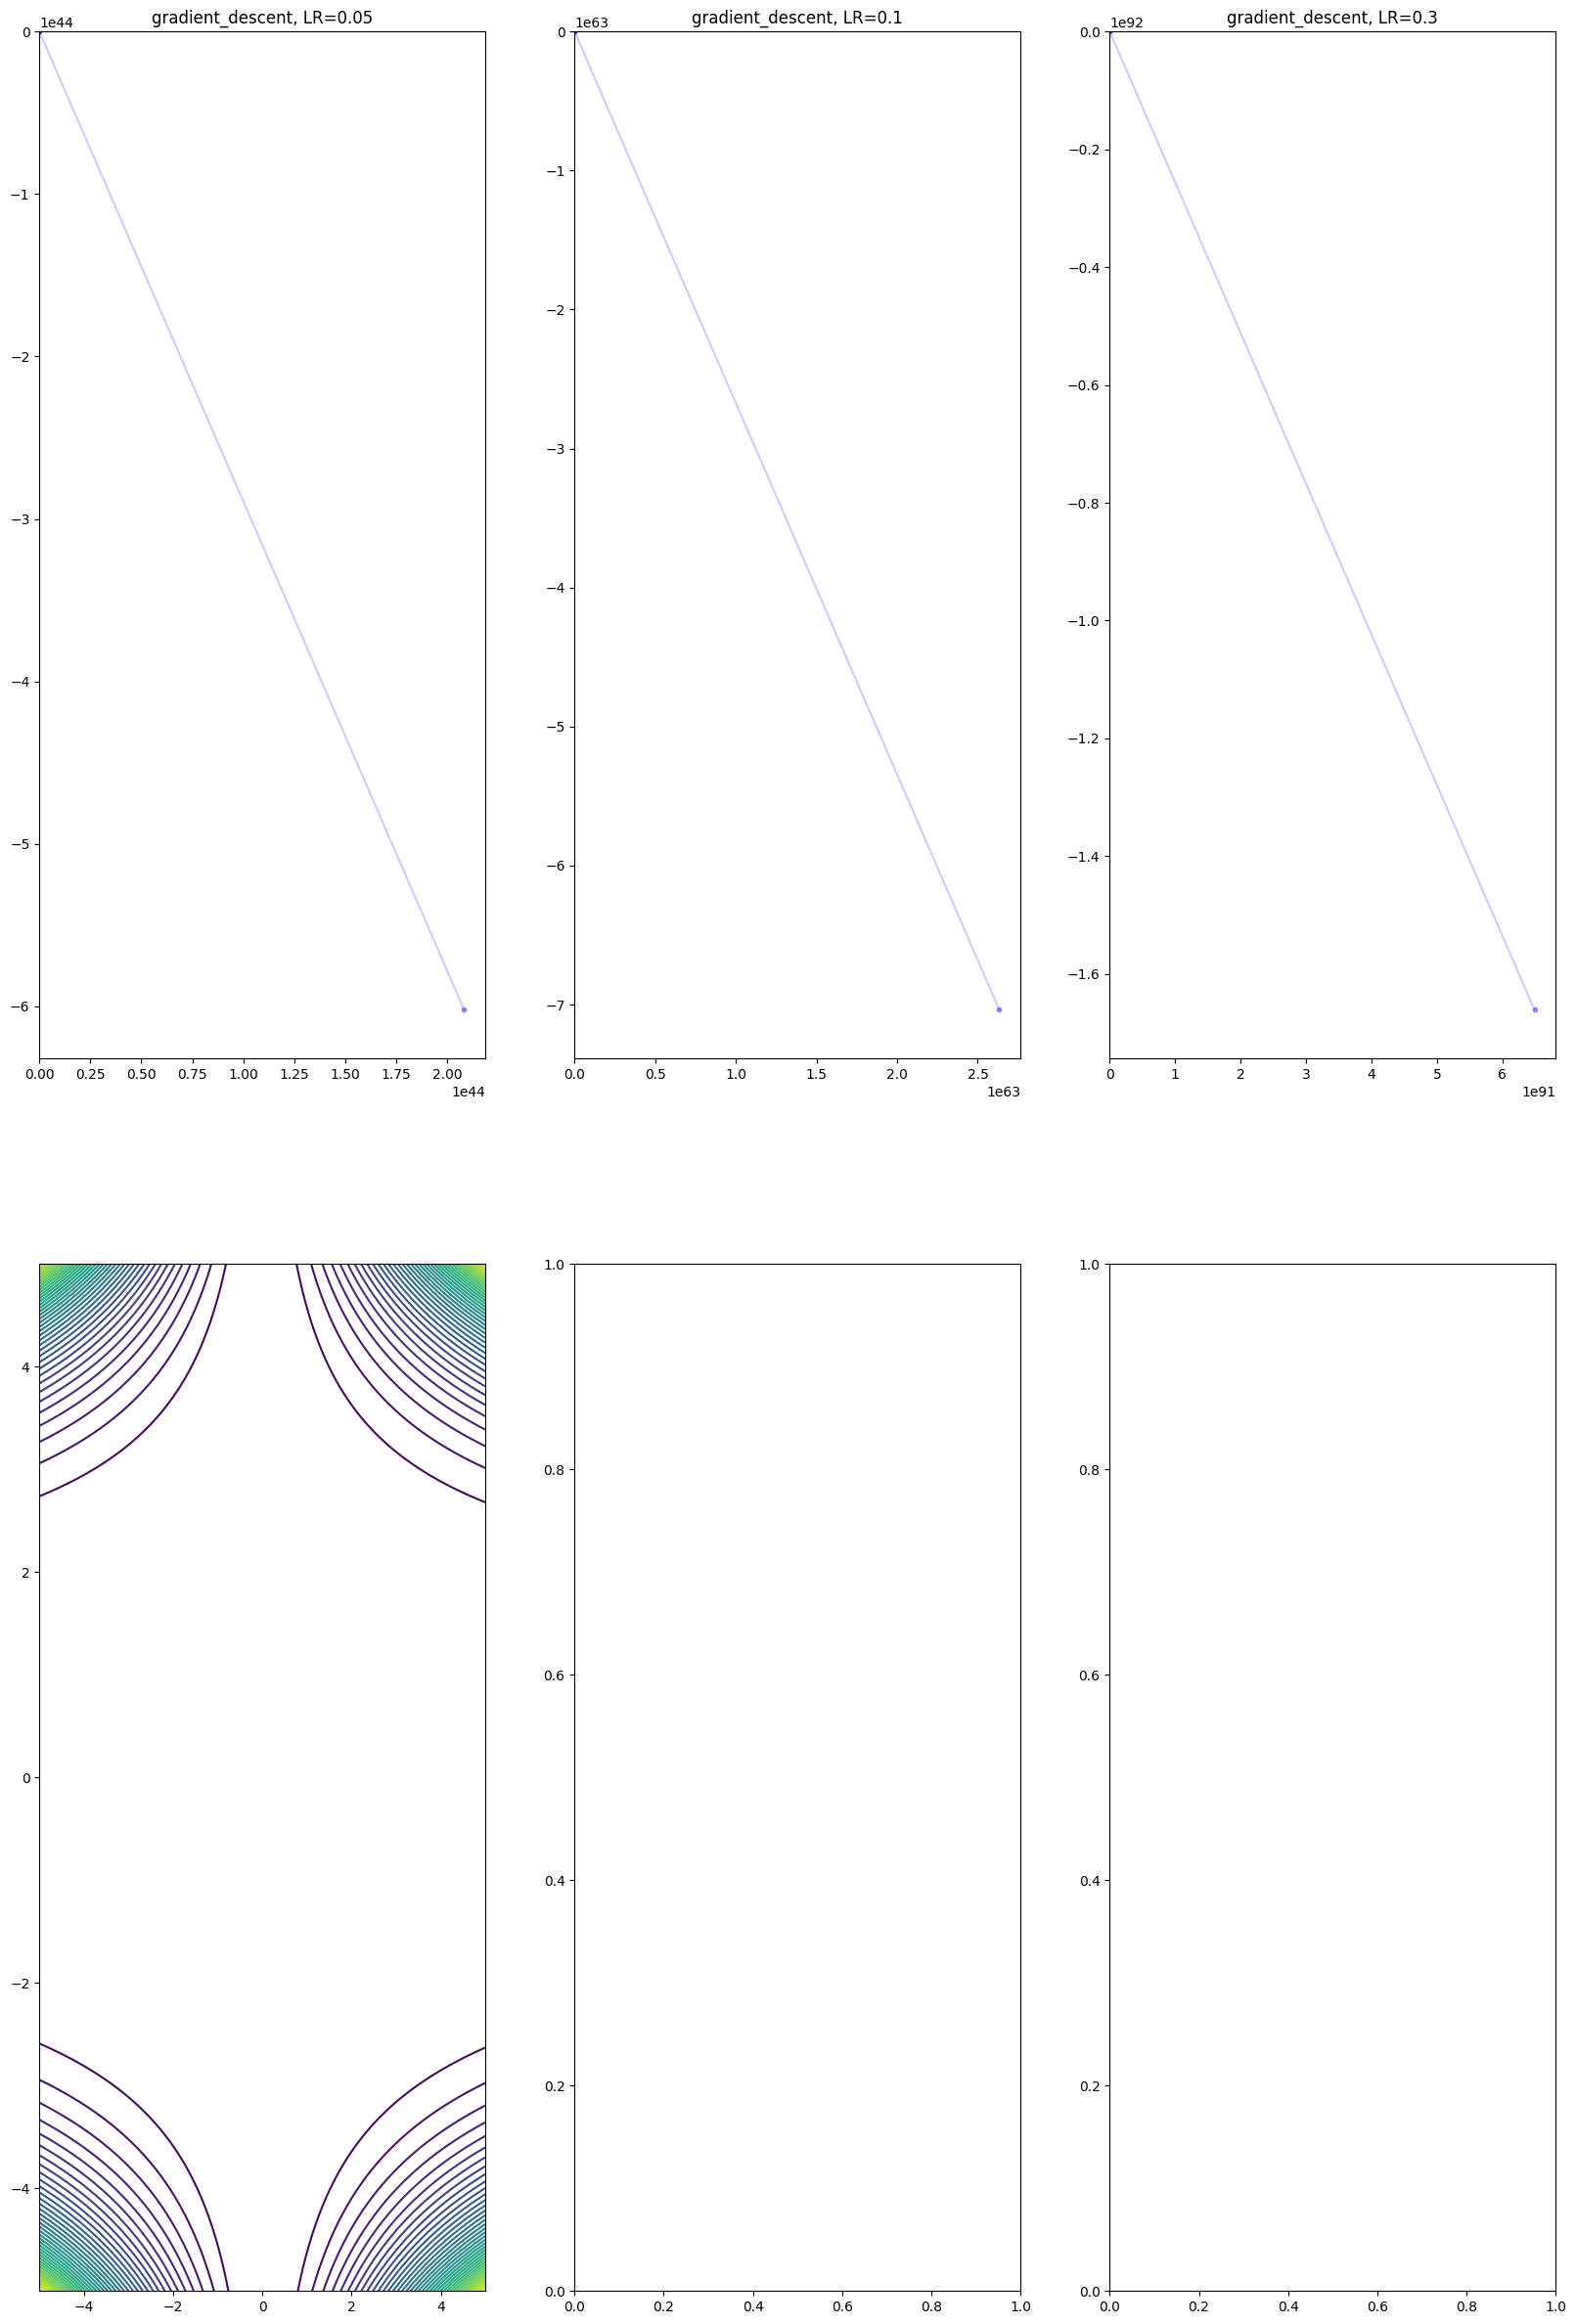

In [14]:
import numpy as np
import matplotlib.pyplot as plt

methods = [  "gradient_descent", "newton"]
learning_rates = [0.05, 0.1, 0.3]
# methods = ["gradient_descent", "heavy_ball", "adam", "adagrad", "rmsprop"]
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_values, y_values)
Z = np.array([beale(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = Z.reshape(X.shape)

# Number of rows is the number of methods, and number of columns is the number of learning rates
fig, axes = plt.subplots(len(methods), len(learning_rates), figsize=(20, 30))

# Iterate over methods and learning rates to populate the grid
for method_idx, method in enumerate(methods):
    for lr_idx, lr in enumerate(learning_rates):
        ax = axes[method_idx, lr_idx]

        # Generate the contour plot for the Rosenbrock function
        ax.contour(X, Y, Z, 50, cmap='viridis')

        # Perform optimization using the specified method and learning rate
        final_iterate, traj = unconstrained_optimization(beale, beale_grad, beale_hessian, learning_rate=lr, num_iterations=1000, method=method, x_init=np.array([-1.5, 2]))
        final_value = beale(final_iterate)
        print(f"Method {method} with learning rate {lr}, the last iterate is {final_iterate}, function value is {final_value:.6f}")

        # Plot the trajectory with gradually changing transparency
        for i in range(len(traj) - 1):
            alpha_value = min(0.8 * (i / len(traj)) + 0.2, 1)  # Keeping alpha within the range [0, 1]
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], '-o', color='blue', alpha=alpha_value, markersize=3)

        # Highlight the end point
        ax.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=5)

        # Set the title for each subplot indicating method and learning rate
        ax.set_title(f"{method}, LR={lr}")

# Adjust layout for clarity
plt.tight_layout()
plt.show()


## Non-Convex Test Functions: The Rosenbrock Function

The Rosenbrock function (also called the **banana function**) is one of the most popular benchmarks for optimization:

$$
f(x, y) = (a - x)^2 + b\,(y - x^2)^2,
$$

with the standard choice $a = 1$, $b = 100$. The global minimum is $f(1, 1) = 0$.

**Why is Rosenbrock hard?** The minimum lies inside a long, narrow, banana-shaped valley. It is easy for an algorithm to find the valley (the term $(a-x)^2$ quickly decreases), but very difficult to navigate along the flat, curved bottom of the valley toward $(1,1)$. The large value of $b$ makes the curvature in the $y$-direction much stronger than in the $x$-direction, creating an extreme aspect ratio in the level sets. This makes Rosenbrock an excellent test for comparing convergence speed of different methods.

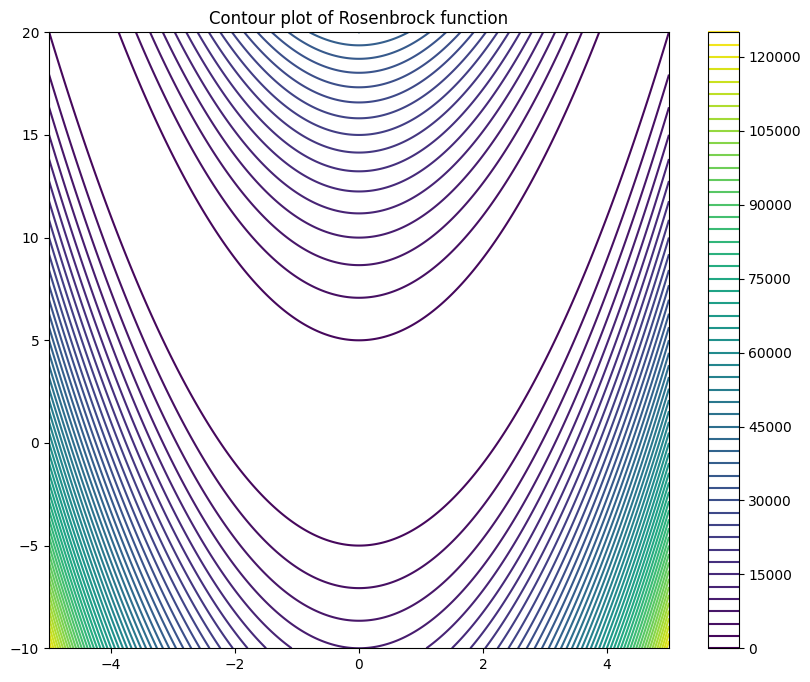

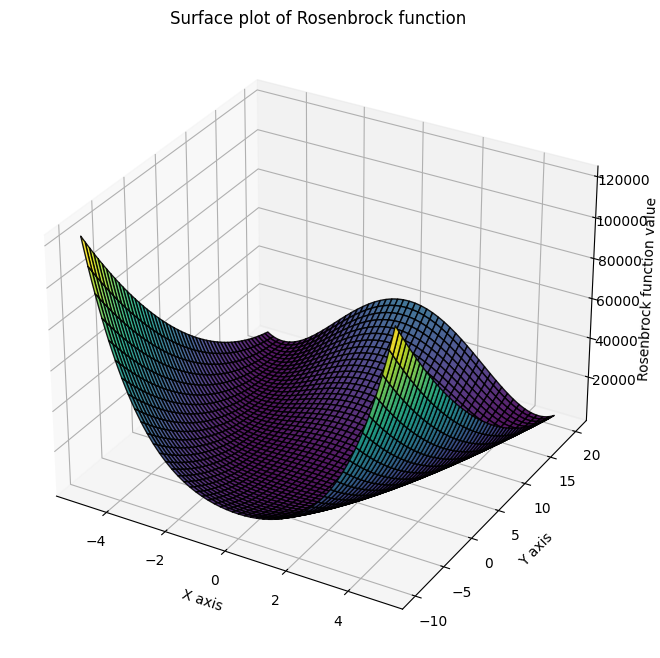

In [15]:
# Redefining the Rosenbrock function and its gradient

def rosenbrock(x, a=1, b=100):
    return (a - x[0])**2 + b * (x[1] - x[0]**2)**2

def rosenbrock_grad(x, a=1, b=100):
    dfdx0 = -2 * (a - x[0]) - 4 * b * x[0] * (x[1] - x[0]**2)
    dfdx1 = 2 * b * (x[1] - x[0]**2)
    return np.array([dfdx0, dfdx1])

def rosenbrock_hessian(x, a=1, b=100):
    x1, x2 = x
    h11 = 2 - 400 * x2 + 1200 * x1**2
    h12 = -400 * x1
    h21 = h12  # Hessian is symmetric
    h22 = 200
    return np.array([[h11, h12], [h21, h22]])




# Generate grid for plotting
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-10, 20, 400)
X, Y = np.meshgrid(x_values, y_values)

# Compute Rosenbrock function values
Z_rosenbrock = np.array([rosenbrock(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z_rosenbrock = Z_rosenbrock.reshape(X.shape)

# Plotting the contour of the Rosenbrock function
plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z_rosenbrock, 50, cmap='viridis')
plt.title('Contour plot of Rosenbrock function')
plt.colorbar()
plt.show()

# Plotting the surface of the Rosenbrock function
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z_rosenbrock, cmap='viridis', alpha=0.9, edgecolor='k')
ax.set_title('Surface plot of Rosenbrock function')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Rosenbrock function value')

plt.show()


In [16]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Define methods and learning rates
methods = ["gradient_descent", "heavy_ball", "coordinate_descent_greedy", "adam", "adagrad"]
learning_rates = [0.0005, 0.001, 0.002, 0.003]

# Generate grid for plotting
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_values, y_values)
Z = np.array([rosenbrock(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = Z.reshape(X.shape)


fig, axes = plt.subplots(len(methods), len(learning_rates), figsize=(20, 20))

# Iterate over methods and learning rates to populate the grid
for method_idx, method in enumerate(methods):
    for lr_idx, lr in enumerate(learning_rates):
        ax = axes[method_idx, lr_idx]

        # Generate the contour plot for the Rosenbrock function
        ax.contour(X, Y, Z, 50, cmap='viridis')

        # Perform optimization using the specified method and learning rate
        final_iterate, traj = unconstrained_optimization(rosenbrock, rosenbrock_grad, rosenbrock_hessian, learning_rate=lr, num_iterations=200, method=method, x_init=np.array([-1.5, 2]))
        final_value = rosenbrock(final_iterate)
        print(f"Method {method} with learning rate {lr}, the last iterate is {final_iterate}, function value is {final_value:.6f}")

        # Plot the trajectory with gradually changing transparency
        for i in range(len(traj) - 1):
            alpha_value = min(0.8 * (i / len(traj)) + 0.2, 1)  # Keeping alpha within the range [0, 1]
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], '-o', color='blue', alpha=alpha_value, markersize=3)

        # Highlight the end point
        ax.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=5)

        # Set the title for each subplot indicating method and learning rate
        ax.set_title(f"{method}, LR={lr}")

# Adjust layout for clarity
plt.tight_layout()
plt.show()



Output hidden; open in https://colab.research.google.com to view.

In [17]:
methods = ["newton", "quasi_newton"]
learning_rates = [0.1, 0.2, 0.3, 1]

# Generate grid for plotting
x_values = np.linspace(-5, 5, 400)
y_values = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_values, y_values)
Z = np.array([rosenbrock(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = Z.reshape(X.shape)


fig, axes = plt.subplots(len(methods), len(learning_rates), figsize=(20, 20))

# Iterate over methods and learning rates to populate the grid
for method_idx, method in enumerate(methods):
    for lr_idx, lr in enumerate(learning_rates):
        ax = axes[method_idx, lr_idx]

        # Generate the contour plot for the Rosenbrock function
        ax.contour(X, Y, Z, 50, cmap='viridis')

        # Perform optimization using the specified method and learning rate
        final_iterate, traj = unconstrained_optimization(rosenbrock, rosenbrock_grad, rosenbrock_hessian, learning_rate=lr, num_iterations=200, method=method, x_init=np.array([-1.5, 2]))
        final_value = rosenbrock(final_iterate)
        print(f"Method {method} with learning rate {lr}, the last iterate is {final_iterate}, function value is {final_value:.6f}")

        # Plot the trajectory with gradually changing transparency
        for i in range(len(traj) - 1):
            alpha_value = min(0.8 * (i / len(traj)) + 0.2, 1)  # Keeping alpha within the range [0, 1]
            ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], '-o', color='blue', alpha=alpha_value, markersize=3)

        # Highlight the end point
        ax.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=5)

        # Set the title for each subplot indicating method and learning rate
        ax.set_title(f"{method}, LR={lr}")

# Adjust layout for clarity
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Summary

This notebook explored several first-order optimization methods on quadratic and non-convex test functions. Key takeaways:

- **Gradient descent** is simple and reliable on well-conditioned problems, but slows dramatically as the condition number $\kappa$ grows.
- **Coordinate descent** updates one variable at a time; the greedy variant can outperform the cyclic variant when gradients are unbalanced across coordinates.
- **Sign gradient descent** uses only gradient signs, giving uniform step sizes in every coordinate -- useful in some distributed settings but not adaptive to curvature.
- **Newton's method** uses second-order (Hessian) information to achieve rapid convergence, but each step is expensive and the method can be unstable on non-convex functions.
- **Heavy ball (momentum)** accelerates convergence by accumulating velocity from past gradients, helping to traverse flat regions faster.
- **Adagrad** adapts the learning rate per coordinate based on accumulated squared gradients; it can handle sparse gradients well but may decay the learning rate too aggressively.
- **RMSProp** fixes Adagrad's aggressive decay by using an exponential moving average of squared gradients.
- **Adam** combines momentum (first moment) with RMSProp-style adaptive rates (second moment) and includes bias correction, making it a robust default choice for many problems.

No single optimizer dominates across all landscapes. The choice of method and learning rate depends heavily on the problem geometry.